# Introduction

The objective of this project is to evaluate the performance and geometric robustness of **Wasserstein K-means clustering** when applied to high-dimensional image data. By utilizing the Wasserstein distance (Earth Mover's Distance) as the underlying metric, this project explores how optimal transport theory can capture structural and spatial correlations in data in comparison with standard Euclidean-based methods.

   

The reference of this project is from the following paper:

Yubo Zhuang, Xiaohui Chen, and Yun Yang. Wasserstein K-means for clustering probability distributions. 2022. arXiv:2209.06975 [stat.ML].
https://arxiv.org/abs/2209.06975


---


**Dataset Composition**

The **Fashion-MNIST** dataset serves as the primary benchmark. Unlike traditional MNIST, Fashion-MNIST consists of more complex spatial structures and texture.

The dataset consists of a training set of 60,000 examples and a test set of 10,000 examples. Each example is a 28x28 grayscale image, associated with a label from 10 distinct classes.
The 10 Categories

Each image is mapped to a specific clothing type:

  - 0: 'T-shirt/top', 1: 'Trouser', 2: 'Pullover', 3: 'Dress', 4: 'Coat',
        5: 'Sandal', 6: 'Shirt', 7: 'Sneaker', 8: 'Bag', 9: 'Ankle boot'

---

**Benchmarking and Evaluation**

To quantify the efficacy of the Wasserstein approach, the project compares its results against two classical clustering paradigms:

 - **Standard K-Means (Euclidean)**: Serving as the baseline, this method minimizes the intra-cluster sum of squares. It assumes isotropic clusters.

 - **Gaussian Mixture Models (GMM)**: A probabilistic approach that uses the Expectation-Maximization (EM) algorithm to fit multi-modal distributions. GMM provides a more flexible covariance structure than K-means.
---

# Libraries



In [ ]:
pip install POT

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.2/40.2 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 20.4 MB/s eta 0:00:00


In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import ot

from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import accuracy_score, normalized_mutual_info_score, adjusted_rand_score
from itertools import permutations


# Theoretical Mathematics Background

##**$K$-means clustering**

Consider a set of possible clusters $\{G_k \}_{k=1}^K
$ whose aim is to partition to dataset $\mathcal{D}$ where $\bigcup_{i=1}^K G_k = \mathcal{D}$, where $G_i \cap G_j = \emptyset$. We aim to find the optimal clusters $\{G_k^* \}_{k=1}^K$ under some distance function d: $\mathcal{X}\times \mathcal{X} \to \mathbb{R}_+.$ We discuss about the **centroid-based** formulation of standard $K$-means, under the Euclidian distance:
\begin{align*}
\min_{\beta_1,\ldots \beta_K \in (\mathbb{R}^d)^K} \sum_{i=1}^n \min_{k\in [K]} \|X_i -\beta_k \|^2_2 = \min_{\beta_1,\ldots \beta_K \in (\mathbb{R}^d)^K} \sum_{k=1}^K\sum_{i\in G_k} \|X_i -\beta_k \|^2_2 = \sum_{k=1}^K\sum_{i\in G_k} \|X_i -\bar{X}_k \|^2_2
\end{align*}
where $\bar{X}_k =\frac{1}{|G_k|}\sum_{i\in G_k} X_i$ and $[K] = \{ 1,\ldots, K\}.$

Applying the parallelogram law for $n$ points: $\sum_{i,j=1}^n\|X_i- X_j \|^2 = 2n \sum_{i=1}^n \|X_i -\bar{X}_n \|^2$ to the loss function we obtain the equivalent **distance-based** formulation $K$-means:
\begin{align*}
\sum_{k=1}^K \frac{1}{2|G_k|} \sum_{i,j\in G_k}\|X_i -X_j \|^2_2
\end{align*}
where we can obmit the scaling factor $1/2$ during the optimization procedures.
Consequently, the both the centroid and distance-based forulations yield the same optimal cluster estimate for $G^*_
1, . . . , G^*_
K.$ Note that the equivalence of these formulation only holds due to the parallelogram law in Euclidian distance.

---


https://www.graphpad.com/guides/prism/latest/statistics/stat_checklist_kmeans_clustering.htm



Recall that Gaussian mixture model (GMM) is a model of the form
\begin{align*}
p_\theta(x) = \sum_{k=1}^K \pi_k \mathscr{G}_{\mu_k,Σ_k} (x) = \sum_{k=1}^K \pi_k \mathcal{N}(x\mid \mu_k, \Sigma_k)
\end{align*}
where $\pi_k > 0$ are the mixture weights satisfying $\sum_{k=1}^K \pi_k = 1$. Additionally, the conditional distribution of a data point assigned to cluster $k$ is $X \mid Z = k \sim \mathcal{N}(\mu_k, \Sigma_k)$.

It is well known that $K$-means algorithm is a special case of a GMM, in which we fix $\Sigma_k = \mathbf{I}_d$ and $\pi_k = 1/K$ for all clusters (so we just have to estimate the cluster means $\{\mu_k\}_{k=1}^K)$ See *Section 21.4.1.1, "K-means is a special case of EM"*, page 730, in Probabilistic Machine Learning: An Introduction by Kevin P. Murphy.

---


The precise $K$-means algorithm is the following: Starting from some initial partition $(G_1^{(0)}, \cdots, G_K^{(0)})$, and given a partition $(G_1^{(t)}, \cdots, G_K^{(t)})$ at step $t \geq 0$:
\begin{align*}
&\text{(i) Compute } \bar{X}_k^{(t)} = \frac{1}{|G_k^{(t)}|}\sum_{X_i \in G_k^{(t)}} X_i \text{ for each } k;\\[6pt]
&\text{(ii) Assign each point: } \quad z_{t+1}(i) \in \underset{1 \leq k \leq K}{\operatorname{argmin}} \left\| X_i - \bar{X}_k^{(t)} \right\|_2;\\[6pt]
&\text{(iii) Update: } \quad G_k^{(t+1)} = \{ X_j \in \mathcal{D} : z_{t+1}(j) = k \}.
\end{align*}



The algorithm is iterated until convergence. Note that the equivalence of update step in both distance-based and centroid-based approaches in $K$-means is the due to the following proposition.

**Proposition**: *Suppose K-means is interpreted as a special case of a GMM with $\Sigma_k = \mathbf{I}_d$ and $\pi_k = 1/K$ for all $k \in [K]$. Then asymptotically as the cluster size $|G_k^{(t)}| \to \infty$, the centroid-based and distance-based assignment rules coincide almost surely. Furthermore, we can write the update rule as:*
\begin{align*}G_k^{(t)} &= \left\{ i \in [n] : \|X_i - \bar{X}_k^{(t)}\|_2 \leq \|X_i - \bar{X}_j^{(t)}\|_2, \forall j \in [K] \right\} \quad \text{(Centroid-based)}\\
&= \left\{ i \in [n] : \frac{1}{|G_k^{(t)}|} \sum_{s \in G_k^{(t)}}\|X_i - X_s \|^2_2 \leqslant \frac{1}{|G_j^{(t)}|} \sum_{s \in G_j^{(t)}} \|X_i - X_s\|_2^2, \quad \forall j \in [K] \right\} \quad \text{(Distance-based)}
\end{align*}



#### *Proof of equivalent formulation.*


Fix an iteration $t \geq 0$. For any $i \in [n]$ and $k \in [K]$:
\begin{align*}
\frac{1}{|G_k|} \sum_{s \in G_k}\|X_i - X_s \|^2_2  
&= \frac{1}{|G_k|} \sum_{s \in G_k}\|(X_i - \bar{X}_k) + (\bar{X}_k - X_s) \|^2_2 \\
&= \frac{1}{|G_k|} \sum_{s \in G_k} \|X_i - \bar{X}_k\|_2^2
+ \frac{1}{|G_k|} \sum_{s \in G_k} \|\bar{X}_k - X_s\|_2^2
+ \frac{2}{|G_k|} \sum_{s \in G_k} \langle X_i - \bar{X}_k,\, \bar{X}_k - X_s \rangle\\
&= \|X_i - \bar{X}_k\|_2^2 + \frac{1}{|G_k|} \sum_{s \in G_k} \|X_s - \bar{X}_k\|_2^2,
\end{align*}
Hence the distance-based assignment rule implies:
\begin{align*}
\|X_i - \bar{X}_k\|_2^2 + \frac{1}{|G_k|} \sum_{s \in G_k} \|X_s - \bar{X}_k\|_2^2
\leq
\|X_i - \bar{X}_j\|_2^2 + \frac{1}{|G_j|} \sum_{s \in G_j} \|X_s - \bar{X}_j\|_2^2,
\quad \forall j \in [K].
\end{align*}
By the Law of Large Numbers:
\begin{align*}
\frac{1}{|G_k|} \sum_{s \in G_k} \|X_s - \bar{X}_k\|_2^2 \xrightarrow[|G_k| \to \infty]{a.s} \text{tr}(\mathbf{I}_d) = d,
\qquad
\frac{1}{|G_j|} \sum_{s \in G_j} \|X_s - \bar{X}_j\|_2^2 \xrightarrow[|G_j| \to \infty]{a.s} \text{tr}(\mathbf{I}_d) = d.
\end{align*}
Since both variance terms converge to the same $d$, they cancel in the inequality, yielding the centroid-based assignment rule.

The reverse direction is trivial by adding $d$ to both sides of the centroid-based inequality and applying the bias-variance decomposition in reverse. $\square$

##**Wasserstein 2-distance**

Let $(\mathcal{X}, \|\cdot\|_2)$ be $\mathbb{R}^d$ equipped with the Euclidean norm, and let $\mu, \nu \in \mathcal{P}_2(\mathbb{R}^d)$, i.e the space of all probability measures on $\mathbb{R}^d$ with finite second moments. The squared Wasserstein 2-distance between $\mu$ and $\nu$ is defined as
\begin{align*}
W_2^2(\mu, \nu) = \inf_{\gamma \in \Gamma(\mu, \nu)} \int_{\mathbb{R}^d \times \mathbb{R}^d} \|x - y\|_2^2 \, d\gamma(x, y),
\end{align*}
where $\Gamma(\mu, \nu)$ denotes the set of all couplings of $\mu$ and $\nu$, i.e., the collection of all Borel probability measures $\gamma$ on $\mathbb{R}^d \times \mathbb{R}^d$ whose marginals are $\mu$ and $\nu$ respectively. Formally, $\gamma \in \Gamma(\mu, \nu)$ if and only if
\begin{align*}
\gamma(A \times \mathbb{R}^d) = \mu(A) \quad \text{and} \quad \gamma(\mathbb{R}^d \times A) = \nu(A)
\end{align*}
for all Borel measurable sets $A \subseteq \mathbb{R}^d$.

---

**The discrete case.**

Now suppose $\mu$ and $\nu$ are discrete measures:
\begin{align*}
\mu = \sum_{l=1}^m w_l \delta_{x_l}, \qquad \nu = \sum_{s=1}^p v_s \delta_{y_s}
\end{align*}
where $w_l \geq 0$, $\sum_{l=1}^m w_l = 1$ and $v_s \geq 0$, $\sum_{s=1}^p v_s = 1$.

**Claim:** Any $\gamma \in \Gamma(\mu, \nu)$ must be of the form:
\begin{align*}
\gamma = \sum_{l=1}^m \sum_{s=1}^p \gamma_{ls} \, \delta_{(x_l, y_s)}, \qquad \gamma_{ls} \geq 0
\end{align*}

*Proof.* For any Borel set $A$ with $A \cap \{x_1, \ldots, x_m\} = \emptyset$. Then:
\begin{align*}
\mu(A) = \sum_{l=1}^m w_l \delta_{x_l}(A) = 0
\end{align*}
By the marginal condition $\gamma(A \times \mathbb{R}^d) = \mu(A) = 0$, so $\gamma$ places no mass outside $\{x_1,\ldots,x_m\}$ in the first coordinate. By the same argument on $\nu$, $\gamma$ places no mass outside $\{y_1,\ldots,y_p\}$ in the second coordinate. Hence $\gamma$ is supported on the finite grid $\{x_l\}_{l=1}^m \times \{y_s\}_{s=1}^p$. $\square$

Hence, the marginal constraints on $\gamma_{ls}$ follow by evaluating on singletons.

For $A = \{x_l\}$,
\begin{align*}
 \mu(\{x_l\}) = w_l \quad \text{so} \quad \gamma(\{x_l\} \times \mathbb{R}^d) =\sum_{s=1}^p \gamma_{ls} = w_l \quad \forall l
\end{align*}
For $A = \{y_s\}$:
\begin{align*}
\nu(\{y_s\}) = v_s \quad \text{so} \quad \gamma(\mathbb{R}^d \times \{y_s\}) = \sum_{l=1}^m \gamma_{ls} = v_s \quad \forall s
\end{align*}


Substituting $\gamma = \sum_{l=1}^m \sum_{s=1}^p   \gamma_{ls} \delta_{(x_l, y_s)}$, the integral reduces to a finite sum:
\begin{align*}
\int_{\mathbb{R}^d \times \mathbb{R}^d} \|x - y\|_2^2 \, d\gamma(x,y)
&= \int_{\mathbb{R}^d \times \mathbb{R}^d} \|x-y\|_2^2 \, d\!\left(\sum_{l=1}^m \sum_{s=1}^p \gamma_{ls}  \delta_{(x_l,y_s)}\right)(x,y) \\
&= \sum_{l=1}^m \sum_{s=1}^p \gamma_{ls} \int_{\mathbb{R}^d \times \mathbb{R}^d} \|x-y\|_2^2 \, d\delta_{(x_l,y_s)}(x,y) \\
&= \sum_{l=1}^m \sum_{s=1}^p \gamma_{ls} \|x_l - y_s\|_2^2
\end{align*}

**Linear Programming Formulation:** the discrete $W_2^2$ becomes a linear programming problem
\begin{align*}
W_2^2(\mu, \nu) = \inf_{\gamma_{ls} \geq 0} \sum_{l=1}^m \sum_{s=1}^p \gamma_{ls} \|x_l - y_s\|_2^2
\end{align*}
subject to:
\begin{align*}
\sum_{s=1}^p \gamma_{ls} = w_l \quad \forall l \in [m], \qquad \sum_{l=1}^m \gamma_{ls} = v_s \quad \forall s \in [p]
\end{align*}

---

**Differences between distances**

In Euclidean space the centroid-based and distance-based formulations of $K$-means are equivalent only because the generalized parallelogram law is valid in Euclidean space. Consequently, minimizing distances to centroids  yields the same partition as minimizing pairwise distances.

In Wasserstein space, these two formulations are NOT equivalent. The parallelogram law fails because Wasserstein space is not a vector space, meaning distributions cannot be linearly averaged. As a result, centroid-based and distance-based formulations optimise different objectives in Wasserstein space and can converge to different clusterings.

---

##**Distance-based Wasserstein $K$-means (D-WKM)**

In Wasserstein space, the data points are probability distributions $\mu_i$. The objective function look similar to Distanced-based Euclidian $K$-means but behave differently.

\begin{align*}
\sum_{k=1}^K \frac{1}{|G_k|} \sum_{i,j\in G_k} W_2^2(\mu_i,\mu_j)
\end{align*}
Correspondingly, we can analogously design an algorithm for the update rule. Given an initial cluster estimate $G_1^{(0)}, \ldots, G_K^{(0)}$, one assigns each probability measure $\mu_1, \ldots, \mu_n$ based on minimizing the averaged squared $W_2$ distances to all current members in every cluster, leading to an updated cluster rule as
\begin{equation}
G_k^{(t+1)} = \left\{ i \in [n] : \frac{1}{|G_k^{(t)}|} \sum_{s \in G_k^{(t)}} W_2^2(\mu_i, \mu_s) \leqslant \frac{1}{|G_j^{(t)}|} \sum_{s \in G_j^{(t)}} W_2^2(\mu_i, \mu_s), \quad \forall j \in [K] \right\}
\end{equation}

---

It is documented in the original paper *''Wasserstein  $K$-means for clustering probability distributions"* by Yubo Zhuang, Xiaohui Chen, Yun Yang that the Centroid-based Wasserstine $K$-means is worse compared to the D-WKM. So here we only focus on D-WKM as the main algorithm.

---

Our data is
$n$ probability distributions $\mu_1, \ldots, \mu_n$​. Each distribution is discrete and represented by two arrays:


- weights — shape $(m,)$, non-negative, sums to 1

- support — shape $(m,d)$, the locations in $\mathbb{R}^d$


In [ ]:
class Distribution:
      def __init__(self, weights, support):
        self.weights = weights  # shape (m,)
        self.support = support  # shape (m, d)

In [ ]:
def compute_w2_squared(mu_i, mu_j):
    """
    Compute W2^2 between two discrete distributions.
    Uses the cost matrix C with elements C[l,s] = ||x_l - x_s||^2.

    Output: squared 2-Wasserstein distance
    """
    # cost matrix: squared Euclidean distance between support points
    C = np.sum((mu_i.support[:, None, :] - mu_j.support[None, :, :]) ** 2, axis=-1)
    # solve OT — use POT library
    w2sq = ot.emd2(mu_i.weights, mu_j.weights, C) # solve the linear programming problem: see ot.emd2 https://pythonot.github.io/all.html#ot.emd2
    return w2sq

In [ ]:
def build_distance_matrix(distributions):
    """
  Input: A list of n probability distributions {μ1,…,μn}

  Output: Solve Optimal Transport (POT library) to get a symmetric matrix Di where Di[i][j] = W_2^2(μi,μj)
   """
    n = len(distributions)
    Di = np.zeros((n, n))
    for i in range(n):
        for j in range(i+1, n):
            d = compute_w2_squared(distributions[i], distributions[j])
            Di[i][j] = d
            Di[j][i] = d
    return Di

In [ ]:
def avg_w2_to_cluster(cluster_members, i, Di):
    """
    average squared Wasserstein distance from a specific distribution μi
    to all distributions currently assigned to a cluster Gk
    """
    if len(cluster_members) == 0:
        return np.inf
    return np.mean([Di[s][i] for s in cluster_members])

In [ ]:
def partition_into_groups_DWKM(n, Di, groups_prev, K):
    """
    Update rule of the Distance-Based Wasserstein K-means
    """
    groups_new = [[] for _ in range(K)]
    for i in range(n):
        best_k = 0
        min_dist = np.inf
        for k in range(K):
            d = avg_w2_to_cluster(groups_prev[k], i, Di)
            if d < min_dist:
                min_dist = d
                best_k = k
        groups_new[best_k].append(i)
    return groups_new

In [ ]:
def initialise_groups(n, K, seed=42):
    """
    randomly assignment each of the n distributions into one of K clusters
    """
    np.random.seed(seed)
    indices = np.random.permutation(n)
    return [list(indices[k::K]) for k in range(K)]

In [ ]:
def initialise_groups_plus(n, K, Di, seed=42):
    """
    K-means++ style initialisation for D-WKM.
    Uses precomputed Di

    Instead of choosing centroids, we choose K 'seed' distributions
    and assign each point to its nearest seed using Di.

    https://www.geeksforgeeks.org/machine-learning/ml-k-means-algorithm/
    """
    np.random.seed(seed)

    # Step 1 — pick first seed uniformly at random
    seeds = [np.random.randint(0, n)]

    # Step 2 — pick remaining seeds with D-WKM++ probability
    for k in range(1, K):
        # for each point, find distance to nearest seed already chosen
        d = np.array([
            min(Di[i][s] for s in seeds)
            for i in range(n)
        ])
        # probability proportional to squared distance
        probs = d ** 2
        probs = probs / probs.sum()
        # sample next seed
        next_seed = np.random.choice(n, p=probs)
        seeds.append(next_seed)

    print(f"Initial seeds: {seeds}")

    # Step 3 — assign each point to nearest seed to form initial partition G_k^(0)
    groups = [[] for _ in range(K)]
    for i in range(n):
        nearest_k = int(np.argmin([Di[i][s] for s in seeds]))
        groups[nearest_k].append(i)

    return groups

In [ ]:
def compute_objective(groups, Di, K):
    """
    sum 1/|G_k| sum over pairs i,j in G_k W_2^2(mu_i,mu_j)
    """
    obj = 0.0
    for k in range(K):
        gk = groups[k]
        if len(gk) == 0:
            continue
        # sum over all pairs (i,j) in G_k x G_k
        pair_sum = sum(Di[i][j] for i in gk for j in gk)
        obj += pair_sum / ( len(gk))
    return obj

In [ ]:
def run_DWKM_with_Di(Di, K, max_iter=100, seed=42, init='plus'):
    """
    Run D-WKM given a precomputed distance matrix Di.
    Does not rebuild Di to avoid recomputation.
    """
    n = Di.shape[0] #precomputed Di

    #initialise partition
    if init == 'plus':
        groups = initialise_groups_plus(n, K, Di, seed)
    else:
        groups = initialise_groups(n, K, seed)

    obj_history = []

    for t in range(max_iter):

        # compute objective
        obj = compute_objective(groups, Di, K)
        obj_history.append(obj)
        # print(f"Iteration {t}: objective={obj:.4f}, "
        #       f"sizes={[len(g) for g in groups]}")

        # assignment step
        groups_new = partition_into_groups_DWKM(n, Di, groups, K)

        if [set(g) for g in groups_new] == [set(g) for g in groups]:
            print(f"Converged at iteration {t+1}")
            groups = groups_new
            break

        groups = groups_new

    # FINAL OUTPUT
    final_obj = obj_history[-1]
    final_sizes = [len(g) for g in groups]
    print(f"Final: objective={final_obj:.4f}, sizes={final_sizes}")

    return groups, obj_history

#Fashion MNIST Clustering



Each MNIST image $I \in [0,1]^{28 \times 28}$ is converted into a discrete probability measure on $\mathbb{R}^2$.

Support: The $28 \times 28 = 784$ pixel coordinates, rescaled to $[0,1]^2$:
$$x_{ij} = \left(\frac{i}{28}, \frac{j}{28}\right) \in [0,1]^2, \quad i,j \in \{0, \ldots, 27\}$$

Weights: Normalized pixel intensities:
$$w_{ij} = \frac{I_{ij}}{\sum_{i,j} I_{ij}}$$

so that $\sum_{i,j} w_{ij} = 1$.

Resulting measure:
$$\mu_I = \sum_{i=0}^{27} \sum_{j=0}^{27} w_{ij}\, \delta_{x_{ij}} = \sum_{l=1}^{784} w_l \delta_{x_l}$$

This is a discrete probability measure supported on a $28 \times 28$ grid in $[0,1]^2$, where mass is
concentrated at pixels proportional to their brightness. A blank image defaults to the
uniform measure $\mu_I = \frac{1}{784} \sum_{i,j} \delta_{x_{ij}}$.

---

The squared Wasserstine distance is:
$$W_2^2(\mu_I, \mu_J) = \inf_{\gamma_{ls} \geq 0} \sum_{l=1}^{784} \sum_{s=1}^{784} \gamma_{ls} \underbrace{\|x_l - x_s\|_2^2}_{C_{l,s}}$$

the cost $C_{l,s} = \|x_l - x_s\|_2^2$ is the **squared Euclidean distance between pixel locations** $l$ and $s$. So moving mass between nearby pixels is cheap, and moving mass between far pixels is expensive.

This means $W_2^2(\mu_I, \mu_J)$ measures how much pixel mass needs to move, and how far, to transform image $I$ into image $J$.

---

This exact linear programming problem computing $W_2$ between ONE pair of images has complexity $O(N^3)$, which is infeasible for large $N$ (Here $N = 784$, so it is computationally expensive). Therefore, in all benchmark comaprison, we only restrict to two class labels with 100 images of class a and 80 images of class b.

Reference: https://lucanenna.github.io/teaching/optimaltransport/lecture2.pdf

In [ ]:
# Turn image to discrete probability distribution
def image_to_distribution(image, rescale=1/28):
    """
    image: shape (28, 28), values in [0, 1]
    """
    h, w = image.shape  # 28, 28

    # Step 1: build support — pixel coordinates in [0,1]^2
    coords = []
    for i in range(h):
        for j in range(w):
            coords.append([i * rescale, j * rescale])
    support = np.array(coords)   # shape (784, 2)

    # Step 2: build weights — normalised pixel intensities
    weights = image.flatten()    # shape (784,)
    total = weights.sum()
    if total == 0:
        weights = np.ones(784) / 784   # uniform if blank image
    else:
        weights = weights / total

    return Distribution(weights=weights, support=support)

## Loading Fashion MNIST and helper functions

In [ ]:
# Load Fashion-MNIST https://github.com/zalandoresearch/fashion-mnist?tab=readme-ov-file
print("Loading Fashion-MNIST dataset...")
(x_train_full, y_train_full), _ = tf.keras.datasets.fashion_mnist.load_data()
x_train_full = x_train_full / 255  # normalize to [0,1]

Loading Fashion-MNIST dataset...


Some helper functions

In [ ]:
def visualize_fashion_mnist_samples(images_a, images_b, class_a, class_b, n_samples=10):
    # Fashion-MNIST class names
    class_names = {
        0: 'T-shirt/top', 1: 'Trouser', 2: 'Pullover', 3: 'Dress', 4: 'Coat',
        5: 'Sandal', 6: 'Shirt', 7: 'Sneaker', 8: 'Bag', 9: 'Ankle boot'}

    # Limit samples
    n_samples = min(n_samples, len(images_a), len(images_b))

    # Create figure
    fig, axes = plt.subplots(2, n_samples, figsize=(2*n_samples, 4))
    fig.suptitle(f'Fashion-MNIST: {class_names[class_a]} (class {class_a}) vs {class_names[class_b]} (class {class_b})',
                 fontsize=14, fontweight='bold')

    # Plot class A samples (top row)
    for i in range(n_samples):
        axes[0, i].imshow(images_a[i], cmap='gray')
        axes[0, i].axis('off')
        if i == 0:
            axes[0, i].set_ylabel(f'{class_names[class_a]}\n(class {class_a})',
                                  fontsize=10, fontweight='bold')

    # Plot class B samples (bottom row)
    for i in range(n_samples):
        axes[1, i].imshow(images_b[i], cmap='gray')
        axes[1, i].axis('off')
        if i == 0:
            axes[1, i].set_ylabel(f'{class_names[class_b]}\n(class {class_b})',
                                  fontsize=10, fontweight='bold')

    plt.tight_layout()
    plt.show()

In [ ]:
class_names = {
    0: 'T-shirt/top', 1: 'Trouser', 2: 'Pullover', 3: 'Dress', 4: 'Coat',
    5: 'Sandal', 6: 'Shirt', 7: 'Sneaker', 8: 'Bag', 9: 'Ankle boot'
}

def plot_pixel_mass(imagesa, imagesb, class_a, class_b, class_names=class_names):
    name_a = class_names[class_a]
    name_b = class_names[class_b]

    mean_a = imagesa.mean(axis=0)
    mean_b = imagesb.mean(axis=0)

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    # --- Vertical pixel mass (row projection) ---
    # Sums all pixel intensities across each row (horizontally), giving one value per row
    # Measures how much brightness is on each horizontal slice of the image
    axes[0].plot(mean_a.sum(axis=1), range(28), color='steelblue', label=name_a)
    axes[0].plot(mean_b.sum(axis=1), range(28), color='tomato',    label=name_b)
    axes[0].invert_yaxis()
    axes[0].set_title('Vertical Pixel Mass\n(row projection)')
    axes[0].set_xlabel('Summed intensity')
    axes[0].set_ylabel('Row (top→bottom)')
    axes[0].legend()

    # --- Horizontal pixel mass (column projection) ---
    # Sums all pixel intensities down each column (vertically), giving one value per column
    # Measures how much brightness is in each vertical slice
    axes[1].plot(mean_a.sum(axis=0), color='steelblue', label=name_a)
    axes[1].plot(mean_b.sum(axis=0), color='tomato',    label=name_b)
    axes[1].set_title('Horizontal Pixel Mass\n(column projection)')
    axes[1].set_xlabel('Column (left→right)')
    axes[1].set_ylabel('Summed intensity')
    axes[1].legend()

    # --- Spatial difference heatmap ---
    # Computes absolute value of mean_class[a] - mean_class[b] pixel by pixel
    diff = mean_a.astype(float) - mean_b.astype(float)
    vmax = np.abs(diff).max()
    im = axes[2].imshow(diff, cmap='RdBu', vmin=-vmax, vmax=vmax, interpolation='nearest')
    axes[2].set_title(f'Spatial Difference\nRed={name_b} dominant | Blue={name_a} dominant')
    axes[2].axis('off')
    plt.colorbar(im, ax=axes[2], fraction=0.046, pad=0.04)

    plt.suptitle(f'Pixel Mass Distribution: {name_a} vs {name_b}', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

Clustering evaluation metrics https://scikit-learn.org/stable/modules/clustering.html#clustering-evaluation

In [ ]:
def evaluate_clustering(final_groups, true_labels, K):
    """
    Evaluate clustering quality using Accuracy, NMI, and ARI.

    Parameters:
    -----------
    final_groups : list of lists
        Cluster assignments, e.g., [[0,1,3], [2,4,5]]
    true_labels : np.ndarray
        Ground truth labels, e.g., [0, 0, 5, 0, 5, ...]
    K : int
        Number of clusters

    Returns:
    --------
    best_acc : float
        Clustering accuracy (0-1) after optimal label matching
    nmi : float
        Normalized Mutual Information (0-1), permutation-invariant
    ari : float
        Adjusted Rand Index (-1 to 1), adjusted for chance
    """
    # total number of samples
    n = len(true_labels)

    # unique true class labels
    unique_labels = np.unique(true_labels)

    # Convert cluster groups to flat predicted labels
    predicted_labels = np.zeros(n, dtype=int)
    for k, group in enumerate(final_groups):
        for idx in group:
            predicted_labels[idx] = k

    # Convert true labels to binary (0, 1) for comparison
    true_labels_binary = np.zeros(n, dtype=int)
    for i, label in enumerate(unique_labels):
        true_labels_binary[true_labels == label] = i

    # Try all permutations to find best label matching
    best_acc = 0
    best_mapping = None
    for perm in permutations(range(K)):
        mapped = np.array([perm[l] for l in predicted_labels])
        acc = accuracy_score(true_labels_binary, mapped)
        if acc > best_acc:
            best_acc = acc
            best_mapping = {k: unique_labels[perm[k]] for k in range(K)}


    # Mutual Info (MI)  compares how much the true cluster labels match with the predicted labels.
    # It shows how much knowing about one cluster helps us predict the other.

    # Compute Normalized Mutual Info (NMI) https://scikit-learn.org/stable/modules/generated/sklearn.metrics.mutual_info_score.html
    #    Higher values mean better agreement between the clusters.
    #    Zero means no agreement.
    nmi = normalized_mutual_info_score(true_labels_binary, predicted_labels) # https://scikit-learn.org/stable/modules/generated/sklearn.metrics.normalized_mutual_info_score.html


    # Rand Index (RI) measures similarity between two clusterings by considering all pairs
    # of points and counting pairs that are assigned in the same/different clusters https://scikit-learn.org/stable/modules/generated/sklearn.metrics.rand_score.html#rbedd61930922-1

    # Compute ARI (Adjusted Rand Index)
    # Interpretation:
    #   ARI = 0  → Random clustering
    #   ARI > 0  → Better than random
    #   ARI = 1  → Perfect clustering
    #   ARI < 0  → Worse than random
    ari = adjusted_rand_score(true_labels_binary, predicted_labels) # https://scikit-learn.org/stable/modules/generated/sklearn.metrics.adjusted_rand_score.html

    return best_acc, nmi, ari


def labels_to_groups(pred_labels, K):
    """
    Convert flat predicted label array to list of K lists of indices.
    """
    return [list(np.where(pred_labels == k)[0]) for k in range(K)]


def print_cluster_composition(final_groups, true_labels):
    """
    Print the class distribution within each cluster (cluster purity check).
    """
    class_names = {
        0: 'T-shirt', 1: 'Trouser', 2: 'Pullover', 3: 'Dress', 4: 'Coat',
        5: 'Sandal', 6: 'Shirt', 7: 'Sneaker', 8: 'Bag', 9: 'Ankle boot'
    }
    for k in range(len(final_groups)):
        cluster_true = true_labels[final_groups[k]]
        counts = np.bincount(cluster_true, minlength=10)
        print(f"  Cluster {k} (size {len(final_groups[k])}): "
              f"{class_names.get(class_a, class_a)} = {counts[class_a]}, "
              f"{class_names.get(class_b, class_b)} = {counts[class_b]}")

In [ ]:
# ──. Final summary
def summarise(results, name):
    accs = [r['acc'] for r in results]
    nmis = [r['nmi'] for r in results]
    aris = [r['ari'] for r in results]
    best = max(accs)
    print(f"{name:<30} acc: {np.mean(accs):.4f} +/- {np.std(accs):.4f} "
          f"(best={best:.4f})  nmi: {np.mean(nmis):.4f} +/- {np.std(nmis):.4f}  "
          f"ari: {np.mean(aris):.4f} +/- {np.std(aris):.4f}")


## T-shirt vs Sandal (Well-Separated Distributions)

In [ ]:
# Fashion-MNIST classes:
# 0: T-shirt/top, 1: Trouser, 2: Pullover, 3: Dress, 4: Coat
# 5: Sandal, 6: Shirt, 7: Sneaker, 8: Bag, 9: Ankle boot

# Select two classes
class_a = 0  # T-shirt/top
class_b = 5  # Sandal

maska = (y_train_full == class_a)
maskb = (y_train_full == class_b)
imagesa = x_train_full[maska][:100] #100 images of class a
imagesb = x_train_full[maskb][:80]  #80 images of class b
images  = np.concatenate([imagesa, imagesb], axis=0)

distributions = [image_to_distribution(images[i]) for i in range(len(images))]
true_labels   = np.array([class_a]*100 + [class_b]*80)
X = images.reshape(len(images), 784)   # for K-means and GMM

Head count check: 100 images of class 0, 80 images of class 5


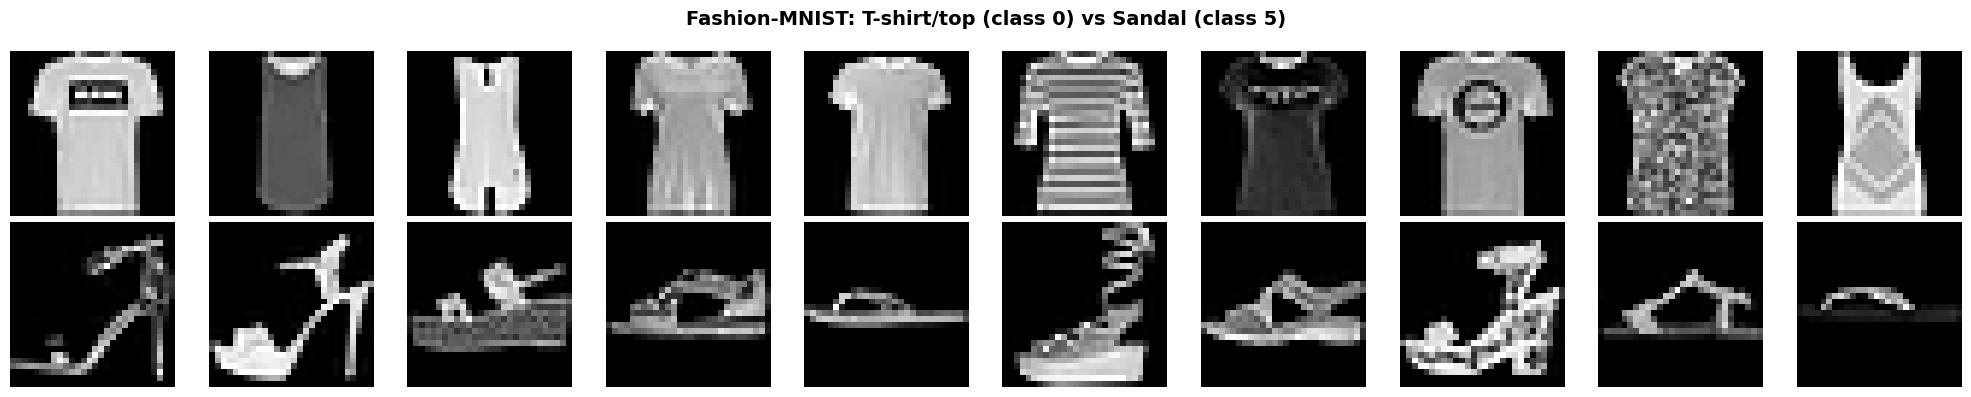

In [ ]:
print(f"Head count check: {len(imagesa)} images of class {class_a}, {len(imagesb)} images of class {class_b}")
visualize_fashion_mnist_samples(imagesa, imagesb, class_a, class_b, n_samples=10)

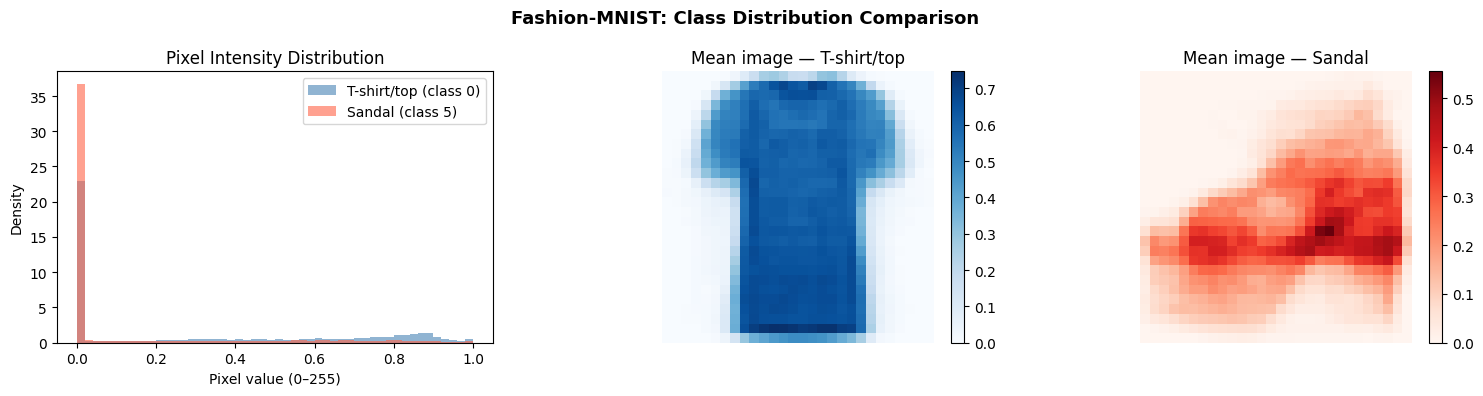

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# --- Plot 1: Overlapping histograms ---
ax = axes[0]
ax.hist(imagesa.flatten(), bins=50, alpha=0.6, color='steelblue', density=True, label='T-shirt/top (class 0)')
ax.hist(imagesb.flatten(), bins=50, alpha=0.6, color='tomato',    density=True, label='Sandal (class 5)')
ax.set_title('Pixel Intensity Distribution')
ax.set_xlabel('Pixel value (0–255)')
ax.set_ylabel('Density')
ax.legend()

# --- Plot 2: Mean image per class ---
for i, (imgs, label, cmap_color) in enumerate([(imagesa, 'T-shirt/top', 'Blues'),
                                                (imagesb, 'Sandal',      'Reds')]):
    ax = axes[i + 1]
    mean_img = imgs.mean(axis=0)
    im = ax.imshow(mean_img, cmap=cmap_color)
    ax.set_title(f'Mean image — {label}')
    ax.axis('off')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.suptitle('Fashion-MNIST: Class Distribution Comparison', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

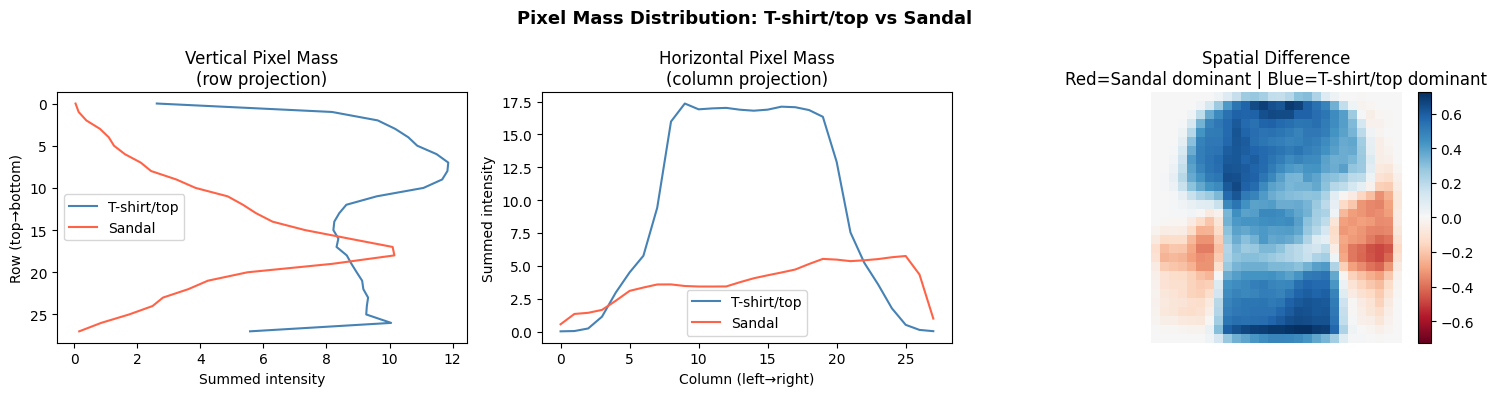

In [ ]:
plot_pixel_mass(imagesa, imagesb, class_a, class_b)

In [ ]:
#  Build Di once for D-WKM
print("Building distance matrix...")
Di = build_distance_matrix(distributions)
print(f"Done. Shape: {Di.shape}\n")

Building distance matrix...
Done. Shape: (180, 180)



In [ ]:
# ── 1. Setup — Fashion-MNIST
K = 2
R = 30  # number of random restarts
seeds = [42, 21, 7, 13, 99, 1, 55, 123, 77, 33,
         17, 82, 256, 512, 64, 101, 200, 37, 150, 29,
         88, 15, 202, 9, 50, 3, 75, 111, 222, 333]

# ── 2. Multiple restarts for D-WKM (random init)
print("="*60)
print("D-WKM — RANDOM INITIALISATION")
print("="*60)
dwkm_random_results = []
for r, seed in enumerate(seeds):
    print(f"\nRestart {r+1}/{R} (seed={seed})")
    groups, obj_history = run_DWKM_with_Di(Di, K=K, max_iter=100, seed=seed, init='random')
    acc, nmi, ari = evaluate_clustering(groups, true_labels, K)
    dwkm_random_results.append({
        'seed': seed, 'groups': groups,
        'obj': obj_history[-1], 'acc': acc, 'nmi': nmi, 'ari': ari
    })
    print(f"  Accuracy={acc:.4f}, NMI={nmi:.4f}, ARI={ari:.4f}, Obj={obj_history[-1]:.4f}")

best_dwkm_random = min(dwkm_random_results, key=lambda x: x['obj'])
print(f"\nBest run (seed={best_dwkm_random['seed']}):")
print_cluster_composition(best_dwkm_random['groups'], true_labels)

# ── 3. Multiple restarts for D-WKM (K-means++ init)
print("\n" + "="*60)
print("D-WKM — K-MEANS++ INITIALISATION")
print("="*60)
dwkm_pp_results = []
for r, seed in enumerate(seeds):
    print(f"\nRestart {r+1}/{R} (seed={seed})")
    groups, obj_history = run_DWKM_with_Di(Di, K=K, max_iter=100, seed=seed, init='plus')
    acc, nmi, ari = evaluate_clustering(groups, true_labels, K)
    dwkm_pp_results.append({
        'seed': seed, 'groups': groups,
        'obj': obj_history[-1], 'acc': acc, 'nmi': nmi, 'ari': ari
    })
    print(f"  Accuracy={acc:.4f}, NMI={nmi:.4f}, ARI={ari:.4f}, Obj={obj_history[-1]:.4f}")

best_dwkm_pp = min(dwkm_pp_results, key=lambda x: x['obj'])
print(f"\nBest run (seed={best_dwkm_pp['seed']}):")
print_cluster_composition(best_dwkm_pp['groups'], true_labels)


D-WKM — RANDOM INITIALISATION

Restart 1/30 (seed=42)
Converged at iteration 3
Final: objective=2.6569, sizes=[100, 80]
  Accuracy=0.9889, NMI=0.9112, ARI=0.9558, Obj=2.6569

Restart 2/30 (seed=21)
Converged at iteration 4
Final: objective=2.6569, sizes=[80, 100]
  Accuracy=0.9889, NMI=0.9112, ARI=0.9558, Obj=2.6569

Restart 3/30 (seed=7)
Converged at iteration 5
Final: objective=2.6569, sizes=[100, 80]
  Accuracy=0.9889, NMI=0.9112, ARI=0.9558, Obj=2.6569

Restart 4/30 (seed=13)
Converged at iteration 2
Final: objective=6.3115, sizes=[180, 0]
  Accuracy=0.5556, NMI=0.0000, ARI=0.0000, Obj=6.3115

Restart 5/30 (seed=99)
Converged at iteration 3
Final: objective=2.6569, sizes=[100, 80]
  Accuracy=0.9889, NMI=0.9112, ARI=0.9558, Obj=2.6569

Restart 6/30 (seed=1)
Converged at iteration 3
Final: objective=2.6569, sizes=[100, 80]
  Accuracy=0.9889, NMI=0.9112, ARI=0.9558, Obj=2.6569

Restart 7/30 (seed=55)
Converged at iteration 3
Final: objective=2.6569, sizes=[80, 100]
  Accuracy=0.9889, 

In [ ]:
# ── 4. Multiple restarts for K-means
print("\n" + "="*60)
print("K-MEANS — MULTIPLE RESTARTS")
print("="*60)
kmeans_results = []
for r, seed in enumerate(seeds):
    print(f"\nRestart {r+1}/{R} (seed={seed})")
    km = KMeans(n_clusters=K, random_state=seed, n_init=1)
    km.fit(X)
    groups = labels_to_groups(km.labels_, K)
    acc, nmi, ari = evaluate_clustering(groups, true_labels, K)
    kmeans_results.append({
        'seed': seed, 'groups': groups,
        'obj': km.inertia_, 'acc': acc, 'nmi': nmi, 'ari': ari
    })
    print(f"  Accuracy={acc:.4f}, NMI={nmi:.4f}, ARI={ari:.4f}, Inertia={km.inertia_:.4f}")

best_kmeans = min(kmeans_results, key=lambda x: x['obj'])
print(f"\nBest run (seed={best_kmeans['seed']}):")
print_cluster_composition(best_kmeans['groups'], true_labels)

# ── 5. Multiple restarts for GMM
print("\n" + "="*60)
print("GMM (full) — MULTIPLE RESTARTS")
print("="*60)
gmm_results = []
for r, seed in enumerate(seeds):
    print(f"\nRestart {r+1}/{R} (seed={seed})")
    gmm = GaussianMixture(n_components=K, covariance_type='full',
                          random_state=seed, n_init=1, max_iter=200)
    gmm.fit(X)
    groups = labels_to_groups(gmm.predict(X), K)
    acc, nmi, ari = evaluate_clustering(groups, true_labels, K)
    gmm_results.append({
        'seed': seed, 'groups': groups,
        'obj': -gmm.lower_bound_, 'acc': acc, 'nmi': nmi, 'ari': ari
    })
    print(f"  Accuracy={acc:.4f}, NMI={nmi:.4f}, ARI={ari:.4f}, Lower bound={gmm.lower_bound_:.4f}")

best_gmm = min(gmm_results, key=lambda x: x['obj'])
print(f"\nBest run (seed={best_gmm['seed']}):")
print_cluster_composition(best_gmm['groups'], true_labels)


K-MEANS — MULTIPLE RESTARTS

Restart 1/30 (seed=42)
  Accuracy=0.9000, NMI=0.6210, ARI=0.6380, Inertia=6557.3357

Restart 2/30 (seed=21)
  Accuracy=0.9056, NMI=0.6345, ARI=0.6560, Inertia=6557.0748

Restart 3/30 (seed=7)
  Accuracy=0.9056, NMI=0.6345, ARI=0.6560, Inertia=6557.0748

Restart 4/30 (seed=13)
  Accuracy=0.8944, NMI=0.6080, ARI=0.6202, Inertia=6557.9981

Restart 5/30 (seed=99)
  Accuracy=0.9056, NMI=0.6345, ARI=0.6560, Inertia=6557.0748

Restart 6/30 (seed=1)
  Accuracy=0.8944, NMI=0.6080, ARI=0.6202, Inertia=6557.9981

Restart 7/30 (seed=55)
  Accuracy=0.8944, NMI=0.6080, ARI=0.6202, Inertia=6557.9981

Restart 8/30 (seed=123)
  Accuracy=0.8944, NMI=0.6080, ARI=0.6202, Inertia=6557.9981

Restart 9/30 (seed=77)
  Accuracy=0.9056, NMI=0.6345, ARI=0.6560, Inertia=6557.0748

Restart 10/30 (seed=33)
  Accuracy=0.8944, NMI=0.6080, ARI=0.6202, Inertia=6557.9981

Restart 11/30 (seed=17)
  Accuracy=0.8944, NMI=0.6080, ARI=0.6202, Inertia=6557.9981

Restart 12/30 (seed=82)
  Accuracy

In [ ]:
print("FINAL SUMMARY — FASHION-MNIST")
print("="*120)
print(f"{'Method':<30} {'Accuracy':<35} {'NMI':<40}  {'ARI':<5}")
print("-"*120)
summarise(dwkm_random_results, "D-WKM (random init)")
summarise(dwkm_pp_results,     "D-WKM (K-means++ init)")
summarise(kmeans_results,      "K-means")
summarise(gmm_results,         "GMM (full)")

FINAL SUMMARY — FASHION-MNIST
Method                         Accuracy                            NMI                                       ARI  
------------------------------------------------------------------------------------------------------------------------
D-WKM (random init)            acc: 0.9744 +/- 0.0778 (best=0.9889)  nmi: 0.8809 +/- 0.1636  ari: 0.9239 +/- 0.1716
D-WKM (K-means++ init)         acc: 0.9889 +/- 0.0000 (best=0.9889)  nmi: 0.9112 +/- 0.0000  ari: 0.9558 +/- 0.0000
K-means                        acc: 0.9004 +/- 0.0054 (best=0.9056)  nmi: 0.6221 +/- 0.0128  ari: 0.6393 +/- 0.0172
GMM (full)                     acc: 0.9004 +/- 0.0054 (best=0.9056)  nmi: 0.6221 +/- 0.0128  ari: 0.6393 +/- 0.0172


## Trouser vs sneaker (Well-Separated Distributions)

In [ ]:
# Fashion-MNIST classes:
# 0: T-shirt/top, 1: Trouser, 2: Pullover, 3: Dress, 4: Coat
# 5: Sandal, 6: Shirt, 7: Sneaker, 8: Bag, 9: Ankle boot

# Select two classes
class_a = 1
class_b = 7

maska = (y_train_full == class_a)
maskb = (y_train_full == class_b)
imagesa = x_train_full[maska][:100] #100 images of class a
imagesb = x_train_full[maskb][:80]  #80 images of class b
images  = np.concatenate([imagesa, imagesb], axis=0)

distributions = [image_to_distribution(images[i]) for i in range(len(images))]
true_labels   = np.array([class_a]*100 + [class_b]*80)
X = images.reshape(len(images), 784)   # for K-means and GMM

Head count check: 100 images of class 1, 80 images of class 7


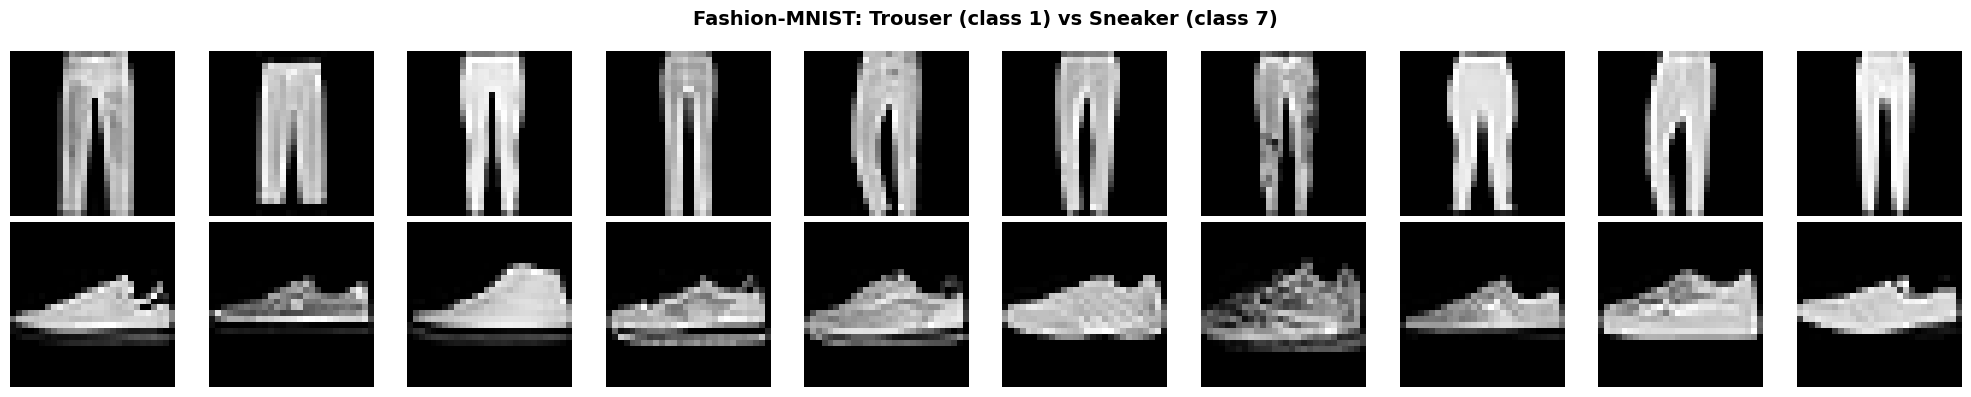

In [ ]:
print(f"Head count check: {len(imagesa)} images of class {class_a}, {len(imagesb)} images of class {class_b}")
visualize_fashion_mnist_samples(imagesa, imagesb, class_a, class_b, n_samples=10)

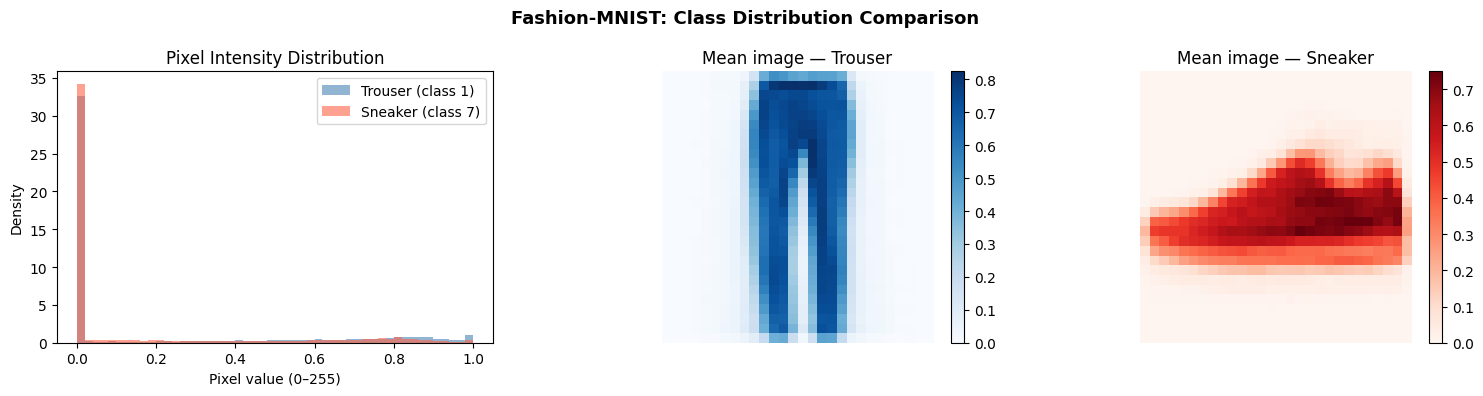

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# --- Plot 1: Overlapping histograms ---
ax = axes[0]
ax.hist(imagesa.flatten(), bins=50, alpha=0.6, color='steelblue', density=True, label='Trouser (class 1)')
ax.hist(imagesb.flatten(), bins=50, alpha=0.6, color='tomato',    density=True, label='Sneaker (class 7)')
ax.set_title('Pixel Intensity Distribution')
ax.set_xlabel('Pixel value (0–255)')
ax.set_ylabel('Density')
ax.legend()

# --- Plot 2: Mean image per class ---
for i, (imgs, label, cmap_color) in enumerate([(imagesa, 'Trouser', 'Blues'),
                                                (imagesb, 'Sneaker',      'Reds')]):
    ax = axes[i + 1]
    mean_img = imgs.mean(axis=0)
    im = ax.imshow(mean_img, cmap=cmap_color)
    ax.set_title(f'Mean image — {label}')
    ax.axis('off')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.suptitle('Fashion-MNIST: Class Distribution Comparison', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

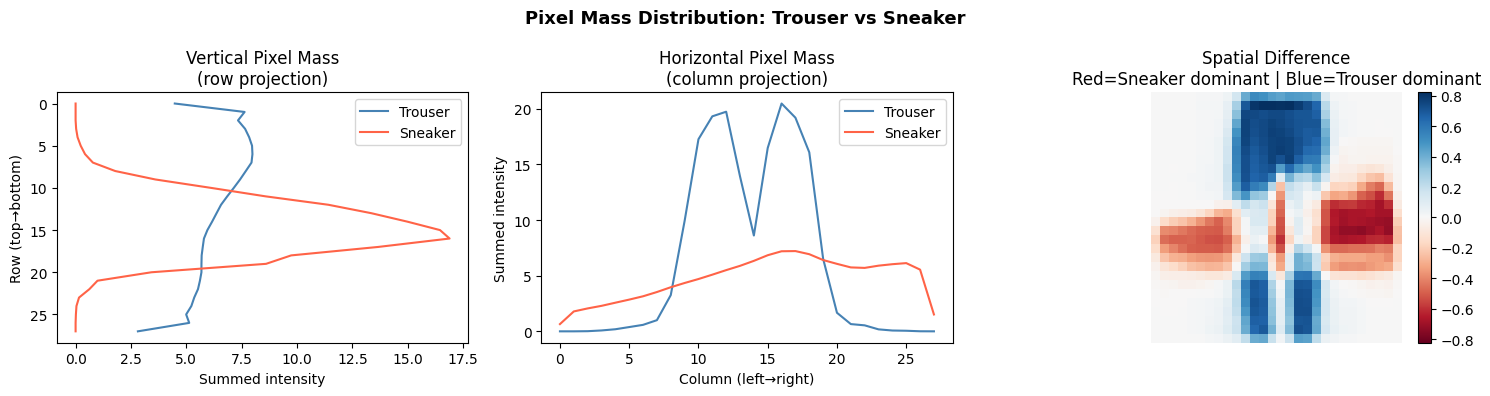

In [ ]:
plot_pixel_mass(imagesa, imagesb, class_a, class_b)

In [ ]:
# ── . Build Di once for D-WKM
print("Building distance matrix...")
Di = build_distance_matrix(distributions)
print(f"Done. Shape: {Di.shape}\n")

Building distance matrix...
Done. Shape: (180, 180)



In [ ]:
# ── 1. Setup — Fashion-MNIST ─────────────────────────────────────────────────
K = 2
R = 30  # number of random restarts
seeds = [42, 21, 7, 13, 99, 1, 55, 123, 77, 33,
         17, 82, 256, 512, 64, 101, 200, 37, 150, 29,
         88, 15, 202, 9, 50, 3, 75, 111, 222, 333]

# ── 2. Multiple restarts for D-WKM (random init) ─────────────────────────────
print("="*60)
print("D-WKM — RANDOM INITIALISATION")
print("="*60)
dwkm_random_results = []
for r, seed in enumerate(seeds):
    print(f"\nRestart {r+1}/{R} (seed={seed})")
    groups, obj_history = run_DWKM_with_Di(Di, K=K, max_iter=100, seed=seed, init='random')
    acc, nmi, ari = evaluate_clustering(groups, true_labels, K)
    dwkm_random_results.append({
        'seed': seed, 'groups': groups,
        'obj': obj_history[-1], 'acc': acc, 'nmi': nmi, 'ari': ari
    })
    print(f"  Accuracy={acc:.4f}, NMI={nmi:.4f}, ARI={ari:.4f}, Obj={obj_history[-1]:.4f}")

best_dwkm_random = min(dwkm_random_results, key=lambda x: x['obj'])
print(f"\nBest run (seed={best_dwkm_random['seed']}):")
print_cluster_composition(best_dwkm_random['groups'], true_labels)

# ── 3. Multiple restarts for D-WKM (K-means++ init) ──────────────────────────
print("\n" + "="*60)
print("D-WKM — K-MEANS++ INITIALISATION")
print("="*60)
dwkm_pp_results = []
for r, seed in enumerate(seeds):
    print(f"\nRestart {r+1}/{R} (seed={seed})")
    groups, obj_history = run_DWKM_with_Di(Di, K=K, max_iter=100, seed=seed, init='plus')
    acc, nmi, ari = evaluate_clustering(groups, true_labels, K)
    dwkm_pp_results.append({
        'seed': seed, 'groups': groups,
        'obj': obj_history[-1], 'acc': acc, 'nmi': nmi, 'ari': ari
    })
    print(f"  Accuracy={acc:.4f}, NMI={nmi:.4f}, ARI={ari:.4f}, Obj={obj_history[-1]:.4f}")

best_dwkm_pp = min(dwkm_pp_results, key=lambda x: x['obj'])
print(f"\nBest run (seed={best_dwkm_pp['seed']}):")
print_cluster_composition(best_dwkm_pp['groups'], true_labels)


D-WKM — RANDOM INITIALISATION

Restart 1/30 (seed=42)
Converged at iteration 2
Final: objective=0.8452, sizes=[100, 80]
  Accuracy=1.0000, NMI=1.0000, ARI=1.0000, Obj=0.8452

Restart 2/30 (seed=21)
Converged at iteration 2
Final: objective=0.8452, sizes=[80, 100]
  Accuracy=1.0000, NMI=1.0000, ARI=1.0000, Obj=0.8452

Restart 3/30 (seed=7)
Converged at iteration 2
Final: objective=0.8452, sizes=[100, 80]
  Accuracy=1.0000, NMI=1.0000, ARI=1.0000, Obj=0.8452

Restart 4/30 (seed=13)
Converged at iteration 2
Final: objective=6.2476, sizes=[180, 0]
  Accuracy=0.5556, NMI=0.0000, ARI=0.0000, Obj=6.2476

Restart 5/30 (seed=99)
Converged at iteration 3
Final: objective=0.8452, sizes=[100, 80]
  Accuracy=1.0000, NMI=1.0000, ARI=1.0000, Obj=0.8452

Restart 6/30 (seed=1)
Converged at iteration 2
Final: objective=0.8452, sizes=[100, 80]
  Accuracy=1.0000, NMI=1.0000, ARI=1.0000, Obj=0.8452

Restart 7/30 (seed=55)
Converged at iteration 2
Final: objective=0.8452, sizes=[80, 100]
  Accuracy=1.0000, 

In [ ]:
# ── 4. Multiple restarts for K-means ─────────────────────────────────────────
print("\n" + "="*60)
print("K-MEANS — MULTIPLE RESTARTS")
print("="*60)
kmeans_results = []
for r, seed in enumerate(seeds):
    print(f"\nRestart {r+1}/{R} (seed={seed})")
    km = KMeans(n_clusters=K, random_state=seed, n_init=1)
    km.fit(X)
    groups = labels_to_groups(km.labels_, K)
    acc, nmi, ari = evaluate_clustering(groups, true_labels, K)
    kmeans_results.append({
        'seed': seed, 'groups': groups,
        'obj': km.inertia_, 'acc': acc, 'nmi': nmi, 'ari': ari
    })
    print(f"  Accuracy={acc:.4f}, NMI={nmi:.4f}, ARI={ari:.4f}, Inertia={km.inertia_:.4f}")

best_kmeans = min(kmeans_results, key=lambda x: x['obj'])
print(f"\nBest run (seed={best_kmeans['seed']}):")
print_cluster_composition(best_kmeans['groups'], true_labels)

# ── 5. Multiple restarts for GMM ─────────────────────────────────────────────
print("\n" + "="*60)
print("GMM (Full) — MULTIPLE RESTARTS")
print("="*60)
gmm_results = []
for r, seed in enumerate(seeds):
    print(f"\nRestart {r+1}/{R} (seed={seed})")
    gmm = GaussianMixture(n_components=K, covariance_type='full',
                          random_state=seed, n_init=1, max_iter=200)
    gmm.fit(X)
    groups = labels_to_groups(gmm.predict(X), K)
    acc, nmi, ari = evaluate_clustering(groups, true_labels, K)
    gmm_results.append({
        'seed': seed, 'groups': groups,
        'obj': -gmm.lower_bound_, 'acc': acc, 'nmi': nmi, 'ari': ari
    })
    print(f"  Accuracy={acc:.4f}, NMI={nmi:.4f}, ARI={ari:.4f}, Lower bound={gmm.lower_bound_:.4f}")
best_gmm = min(gmm_results, key=lambda x: x['obj'])
print(f"\nBest run (seed={best_gmm['seed']}):")
print_cluster_composition(best_gmm['groups'], true_labels)


K-MEANS — MULTIPLE RESTARTS

Restart 1/30 (seed=42)
  Accuracy=0.9889, NMI=0.9225, ARI=0.9558, Inertia=4311.7306

Restart 2/30 (seed=21)
  Accuracy=0.9889, NMI=0.9225, ARI=0.9558, Inertia=4311.7306

Restart 3/30 (seed=7)
  Accuracy=0.9889, NMI=0.9225, ARI=0.9558, Inertia=4311.7306

Restart 4/30 (seed=13)
  Accuracy=0.9889, NMI=0.9225, ARI=0.9558, Inertia=4311.7306

Restart 5/30 (seed=99)
  Accuracy=0.9889, NMI=0.9225, ARI=0.9558, Inertia=4311.7306

Restart 6/30 (seed=1)
  Accuracy=0.9889, NMI=0.9225, ARI=0.9558, Inertia=4311.7306

Restart 7/30 (seed=55)
  Accuracy=0.9889, NMI=0.9225, ARI=0.9558, Inertia=4311.7306

Restart 8/30 (seed=123)
  Accuracy=0.9889, NMI=0.9225, ARI=0.9558, Inertia=4311.7306

Restart 9/30 (seed=77)
  Accuracy=0.9889, NMI=0.9225, ARI=0.9558, Inertia=4311.7306

Restart 10/30 (seed=33)
  Accuracy=0.9889, NMI=0.9225, ARI=0.9558, Inertia=4311.7306

Restart 11/30 (seed=17)
  Accuracy=0.9889, NMI=0.9225, ARI=0.9558, Inertia=4311.7306

Restart 12/30 (seed=82)
  Accuracy

In [ ]:
print("FINAL SUMMARY — FASHION-MNIST")
print("="*120)
print(f"{'Method':<30} {'Accuracy':<35} {'NMI':<40}  {'ARI':<5}")
print("-"*120)
summarise(dwkm_random_results, "D-WKM (random init)")
summarise(dwkm_pp_results,     "D-WKM (K-means++ init)")
summarise(kmeans_results,      "K-means")
summarise(gmm_results,         "GMM (full)")

FINAL SUMMARY — FASHION-MNIST
Method                         Accuracy                            NMI                                       ARI  
------------------------------------------------------------------------------------------------------------------------
D-WKM (random init)            acc: 0.9852 +/- 0.0798 (best=1.0000)  nmi: 0.9667 +/- 0.1795  ari: 0.9667 +/- 0.1795
D-WKM (K-means++ init)         acc: 1.0000 +/- 0.0000 (best=1.0000)  nmi: 1.0000 +/- 0.0000  ari: 1.0000 +/- 0.0000
K-means                        acc: 0.9889 +/- 0.0000 (best=0.9889)  nmi: 0.9225 +/- 0.0000  ari: 0.9558 +/- 0.0000
GMM (full)                     acc: 0.9889 +/- 0.0000 (best=0.9889)  nmi: 0.9225 +/- 0.0000  ari: 0.9558 +/- 0.0000


## Shirt vs Dress (Moderately Separated Distributions)

In [ ]:
# Fashion-MNIST classes:
# 0: T-shirt/top, 1: Trouser, 2: Pullover, 3: Dress, 4: Coat
# 5: Sandal, 6: Shirt, 7: Sneaker, 8: Bag, 9: Ankle boot

# Select two classes
class_a = 6  # Shirt
class_b = 3  # Dress

maska = (y_train_full == class_a)
maskb = (y_train_full == class_b)
imagesa = x_train_full[maska][:100] #100 images of class a
imagesb = x_train_full[maskb][:80]  #80 images of class b
images  = np.concatenate([imagesa, imagesb], axis=0)

distributions = [image_to_distribution(images[i]) for i in range(len(images))]
true_labels   = np.array([class_a]*100 + [class_b]*80)
X = images.reshape(len(images), 784)   # for K-means and GMM

Head count check: 100 images of class 6, 80 images of class 3


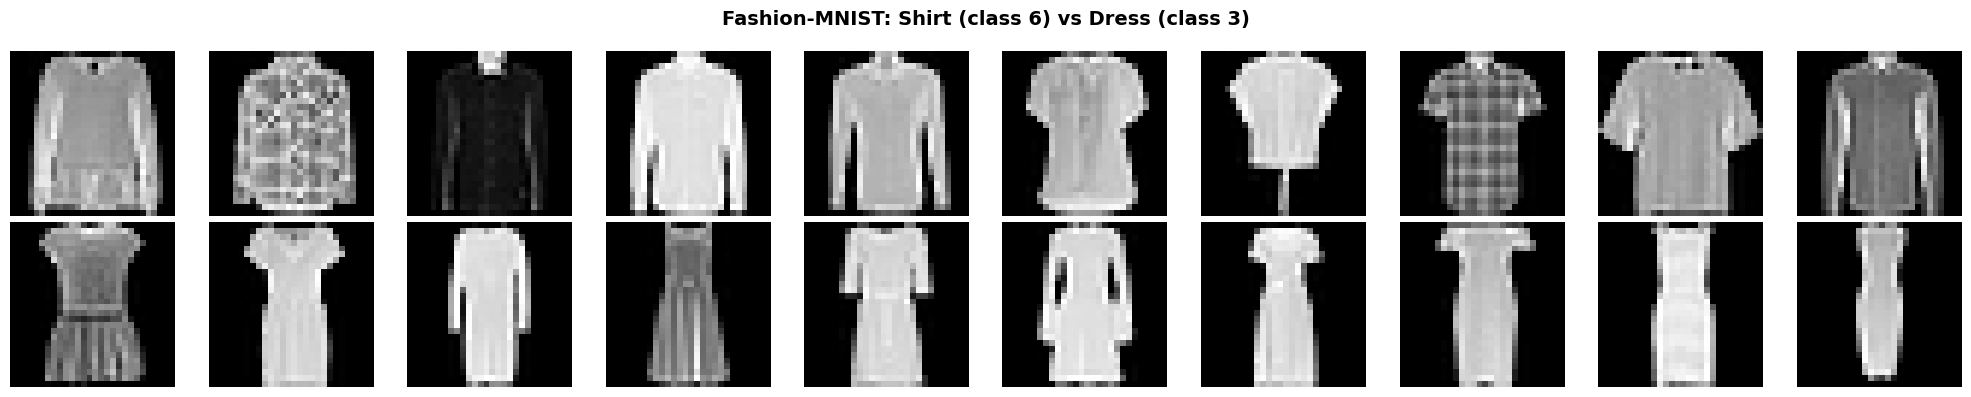

In [ ]:
print(f"Head count check: {len(imagesa)} images of class {class_a}, {len(imagesb)} images of class {class_b}")
visualize_fashion_mnist_samples(imagesa, imagesb, class_a, class_b, n_samples=10)

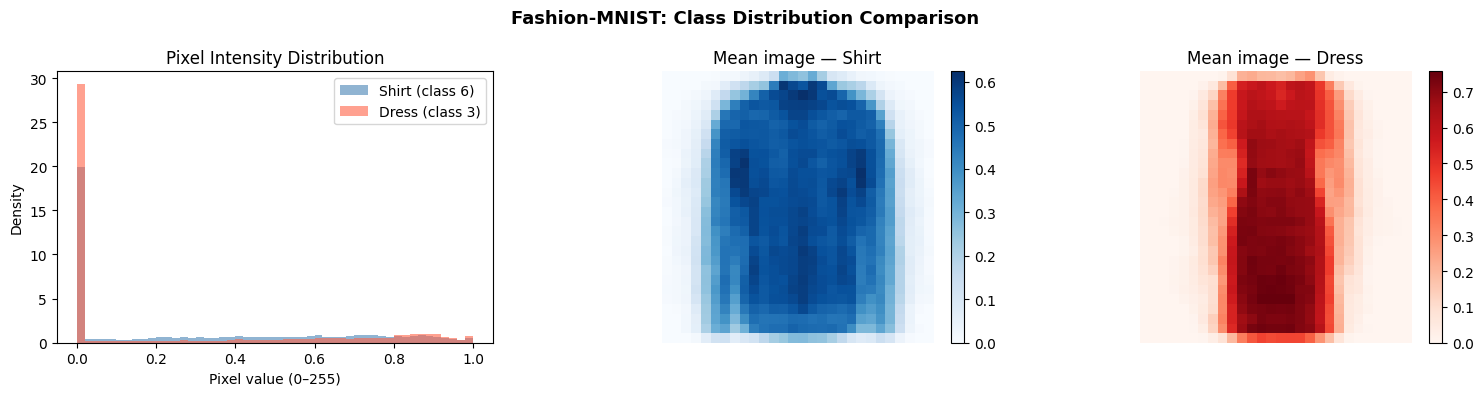

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# --- Plot 1: Overlapping histograms ---
ax = axes[0]
ax.hist(imagesa.flatten(), bins=50, alpha=0.6, color='steelblue', density=True, label='Shirt (class 6)')
ax.hist(imagesb.flatten(), bins=50, alpha=0.6, color='tomato',    density=True, label='Dress (class 3)')
ax.set_title('Pixel Intensity Distribution')
ax.set_xlabel('Pixel value (0–255)')
ax.set_ylabel('Density')
ax.legend()

# --- Plot 2: Mean image per class ---
for i, (imgs, label, cmap_color) in enumerate([(imagesa, 'Shirt', 'Blues'),
                                                (imagesb, 'Dress',      'Reds')]):
    ax = axes[i + 1]
    mean_img = imgs.mean(axis=0)
    im = ax.imshow(mean_img, cmap=cmap_color)
    ax.set_title(f'Mean image — {label}')
    ax.axis('off')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.suptitle('Fashion-MNIST: Class Distribution Comparison', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

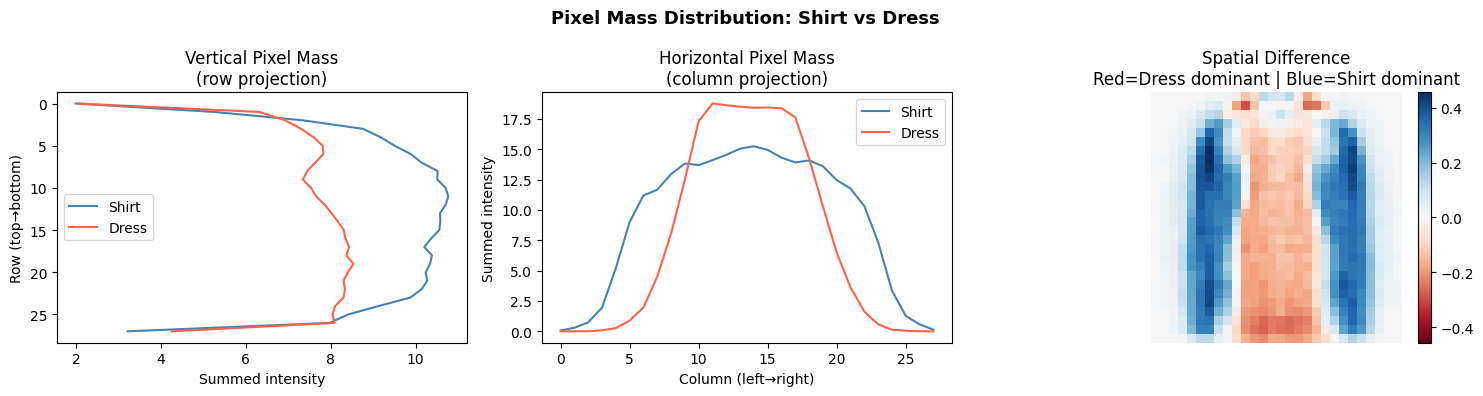

In [ ]:
plot_pixel_mass(imagesa, imagesb, class_a, class_b)

In [ ]:
#  Build Di once for D-WKM
print("Building distance matrix...")
Di = build_distance_matrix(distributions)
print(f"Done. Shape: {Di.shape}\n")

Building distance matrix...
Done. Shape: (180, 180)



In [ ]:
# ── 1. Setup — Fashion-MNIST
K = 2
R = 30  # number of random restarts
seeds = [42, 21, 7, 13, 99, 1, 55, 123, 77, 33,
         17, 82, 256, 512, 64, 101, 200, 37, 150, 29,
         88, 15, 202, 9, 50, 3, 75, 111, 222, 333]

# R = 50  # number of random restarts
# seeds = [42, 21, 7, 13, 99, 1, 55, 123, 77, 33,
#          17, 82, 256, 512, 64, 101, 200, 37, 150, 29,
#          88, 15, 202, 9, 50, 3, 75, 111, 222, 333,
#          5, 11, 23, 31, 44, 66, 100, 128, 144, 169,
#          180, 199, 240, 300, 365, 400, 500, 600, 777, 1000]

# ── 2. Multiple restarts for D-WKM (random init)
print("="*60)
print("D-WKM — RANDOM INITIALISATION")
print("="*60)
dwkm_random_results = []
for r, seed in enumerate(seeds):
    print(f"\nRestart {r+1}/{R} (seed={seed})")
    groups, obj_history = run_DWKM_with_Di(Di, K=K, max_iter=100, seed=seed, init='random')
    acc, nmi, ari = evaluate_clustering(groups, true_labels, K)
    dwkm_random_results.append({
        'seed': seed, 'groups': groups,
        'obj': obj_history[-1], 'acc': acc, 'nmi': nmi, 'ari': ari
    })
    print(f"  Accuracy={acc:.4f}, NMI={nmi:.4f}, ARI={ari:.4f}, Obj={obj_history[-1]:.4f}")

best_dwkm_random = min(dwkm_random_results, key=lambda x: x['obj'])
print(f"\nBest run (seed={best_dwkm_random['seed']}):")
print_cluster_composition(best_dwkm_random['groups'], true_labels)

# ── 3. Multiple restarts for D-WKM (K-means++ init)
print("\n" + "="*60)
print("D-WKM — K-MEANS++ INITIALISATION")
print("="*60)
dwkm_pp_results = []
for r, seed in enumerate(seeds):
    print(f"\nRestart {r+1}/{R} (seed={seed})")
    groups, obj_history = run_DWKM_with_Di(Di, K=K, max_iter=100, seed=seed, init='plus')
    acc, nmi, ari = evaluate_clustering(groups, true_labels, K)
    dwkm_pp_results.append({
        'seed': seed, 'groups': groups,
        'obj': obj_history[-1], 'acc': acc, 'nmi': nmi, 'ari': ari
    })
    print(f"  Accuracy={acc:.4f}, NMI={nmi:.4f}, ARI={ari:.4f}, Obj={obj_history[-1]:.4f}")

best_dwkm_pp = min(dwkm_pp_results, key=lambda x: x['obj'])
print(f"\nBest run (seed={best_dwkm_pp['seed']}):")
print_cluster_composition(best_dwkm_pp['groups'], true_labels)


D-WKM — RANDOM INITIALISATION

Restart 1/30 (seed=42)
Converged at iteration 6
Final: objective=1.3176, sizes=[99, 81]
  Accuracy=0.8833, NMI=0.4773, ARI=0.5855, Obj=1.3176

Restart 2/30 (seed=21)
Converged at iteration 5
Final: objective=1.3173, sizes=[82, 98]
  Accuracy=0.8778, NMI=0.4620, ARI=0.5685, Obj=1.3173

Restart 3/30 (seed=7)
Converged at iteration 5
Final: objective=1.3167, sizes=[101, 79]
  Accuracy=0.8722, NMI=0.4448, ARI=0.5517, Obj=1.3167

Restart 4/30 (seed=13)
Converged at iteration 15
Final: objective=1.3167, sizes=[79, 101]
  Accuracy=0.8722, NMI=0.4448, ARI=0.5517, Obj=1.3167

Restart 5/30 (seed=99)
Converged at iteration 8
Final: objective=1.3168, sizes=[100, 80]
  Accuracy=0.8778, NMI=0.4607, ARI=0.5684, Obj=1.3168

Restart 6/30 (seed=1)
Converged at iteration 3
Final: objective=1.9096, sizes=[180, 0]
  Accuracy=0.5556, NMI=0.0000, ARI=0.0000, Obj=1.9096

Restart 7/30 (seed=55)
Converged at iteration 6
Final: objective=1.3167, sizes=[79, 101]
  Accuracy=0.8722, N

In [ ]:
# ── 4. Multiple restarts for K-means
print("\n" + "="*60)
print("K-MEANS — MULTIPLE RESTARTS")
print("="*60)
kmeans_results = []
for r, seed in enumerate(seeds):
    print(f"\nRestart {r+1}/{R} (seed={seed})")
    km = KMeans(n_clusters=K, random_state=seed, n_init=1)
    km.fit(X)
    groups = labels_to_groups(km.labels_, K)
    acc, nmi, ari = evaluate_clustering(groups, true_labels, K)
    kmeans_results.append({
        'seed': seed, 'groups': groups,
        'obj': km.inertia_, 'acc': acc, 'nmi': nmi, 'ari': ari
    })
    print(f"  Accuracy={acc:.4f}, NMI={nmi:.4f}, ARI={ari:.4f}, Inertia={km.inertia_:.4f}")

best_kmeans = min(kmeans_results, key=lambda x: x['obj'])
print(f"\nBest run (seed={best_kmeans['seed']}):")
print_cluster_composition(best_kmeans['groups'], true_labels)

# ── 5. Multiple restarts for GMM
print("\n" + "="*60)
print("GMM (full) — MULTIPLE RESTARTS")
print("="*60)
gmm_results = []
for r, seed in enumerate(seeds):
    print(f"\nRestart {r+1}/{R} (seed={seed})")
    gmm = GaussianMixture(n_components=K, covariance_type='full',
                          random_state=seed, n_init=1, max_iter=200)
    gmm.fit(X)
    groups = labels_to_groups(gmm.predict(X), K)
    acc, nmi, ari = evaluate_clustering(groups, true_labels, K)
    gmm_results.append({
        'seed': seed, 'groups': groups,
        'obj': -gmm.lower_bound_, 'acc': acc, 'nmi': nmi, 'ari': ari
    })
    print(f"  Accuracy={acc:.4f}, NMI={nmi:.4f}, ARI={ari:.4f}, Lower bound={gmm.lower_bound_:.4f}")

best_gmm = min(gmm_results, key=lambda x: x['obj'])
print(f"\nBest run (seed={best_gmm['seed']}):")
print_cluster_composition(best_gmm['groups'], true_labels)


K-MEANS — MULTIPLE RESTARTS

Restart 1/30 (seed=42)
  Accuracy=0.6833, NMI=0.1336, ARI=0.1293, Inertia=7026.9936

Restart 2/30 (seed=21)
  Accuracy=0.6944, NMI=0.1452, ARI=0.1462, Inertia=7027.9000

Restart 3/30 (seed=7)
  Accuracy=0.6722, NMI=0.1018, ARI=0.1136, Inertia=7033.8034

Restart 4/30 (seed=13)
  Accuracy=0.7167, NMI=0.1938, ARI=0.1828, Inertia=7048.6189

Restart 5/30 (seed=99)
  Accuracy=0.6722, NMI=0.1018, ARI=0.1136, Inertia=7033.8034

Restart 6/30 (seed=1)
  Accuracy=0.7167, NMI=0.1938, ARI=0.1828, Inertia=7048.6189

Restart 7/30 (seed=55)
  Accuracy=0.6889, NMI=0.1393, ARI=0.1376, Inertia=7027.8269

Restart 8/30 (seed=123)
  Accuracy=0.6889, NMI=0.1349, ARI=0.1377, Inertia=7027.1334

Restart 9/30 (seed=77)
  Accuracy=0.6889, NMI=0.1349, ARI=0.1377, Inertia=7027.1334

Restart 10/30 (seed=33)
  Accuracy=0.6833, NMI=0.1336, ARI=0.1293, Inertia=7026.9936

Restart 11/30 (seed=17)
  Accuracy=0.6833, NMI=0.1336, ARI=0.1293, Inertia=7026.9936

Restart 12/30 (seed=82)
  Accuracy

In [ ]:
print("FINAL SUMMARY — FASHION-MNIST")
print("="*120)
print(f"{'Method':<30} {'Accuracy':<35} {'NMI':<40}  {'ARI':<5}")
print("-"*120)
summarise(dwkm_random_results, "D-WKM (random init)")
summarise(dwkm_pp_results,     "D-WKM (K-means++ init)")
summarise(kmeans_results,      "K-means")
summarise(gmm_results,         "GMM (full)")

FINAL SUMMARY — FASHION-MNIST
Method                         Accuracy                            NMI                                       ARI  
------------------------------------------------------------------------------------------------------------------------
D-WKM (random init)            acc: 0.8320 +/- 0.1135 (best=0.8833)  nmi: 0.3990 +/- 0.1498  ari: 0.4888 +/- 0.1940
D-WKM (K-means++ init)         acc: 0.7765 +/- 0.1528 (best=0.8833)  nmi: 0.3259 +/- 0.2014  ari: 0.3939 +/- 0.2610
K-means                        acc: 0.6957 +/- 0.0178 (best=0.7167)  nmi: 0.1514 +/- 0.0365  ari: 0.1495 +/- 0.0281
GMM (full)                     acc: 0.6957 +/- 0.0178 (best=0.7167)  nmi: 0.1514 +/- 0.0365  ari: 0.1495 +/- 0.0281


## T-shirt vs Pullover (Moderately Separated Distributions)

In [ ]:
# Fashion-MNIST classes:
# 0: T-shirt/top, 1: Trouser, 2: Pullover, 3: Dress, 4: Coat
# 5: Sandal, 6: Shirt, 7: Sneaker, 8: Bag, 9: Ankle boot

# Select two classes
class_a = 0  # T-Shirt
class_b = 2  # Pullover

maska = (y_train_full == class_a)
maskb = (y_train_full == class_b)
imagesa = x_train_full[maska][:100] #100 images of class a
imagesb = x_train_full[maskb][:80]  #80 images of class b
images  = np.concatenate([imagesa, imagesb], axis=0)

distributions = [image_to_distribution(images[i]) for i in range(len(images))]
true_labels   = np.array([class_a]*100 + [class_b]*80)
X = images.reshape(len(images), 784)   # for K-means and GMM

Head count check: 100 images of class 0, 80 images of class 2


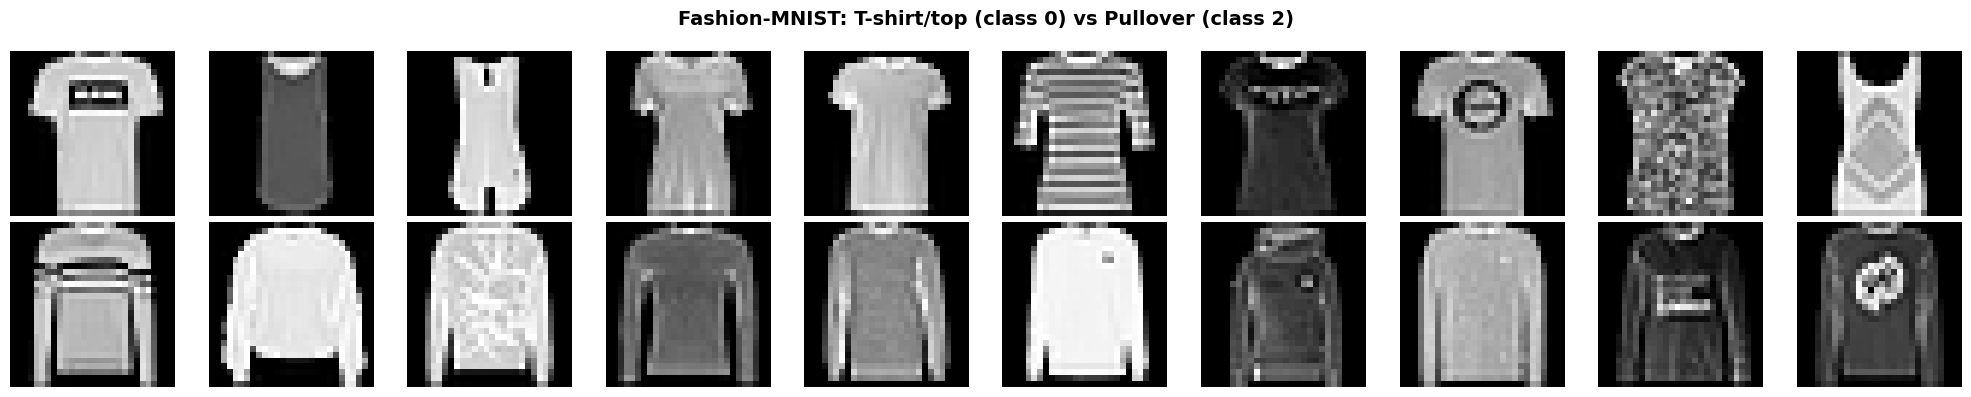

In [ ]:
print(f"Head count check: {len(imagesa)} images of class {class_a}, {len(imagesb)} images of class {class_b}")
visualize_fashion_mnist_samples(imagesa, imagesb, class_a, class_b, n_samples=10)

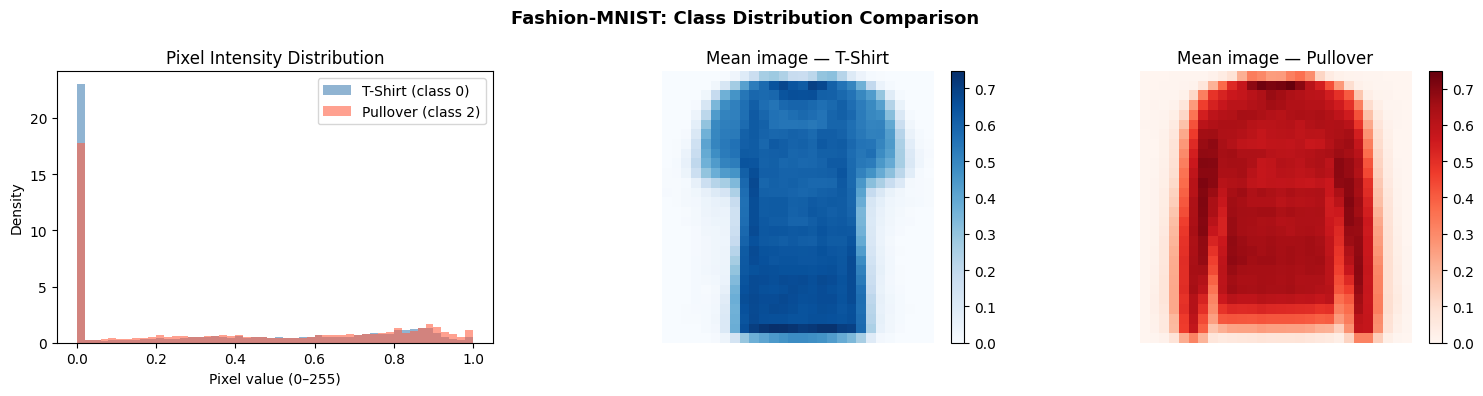

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# --- Plot 1: Overlapping histograms ---
ax = axes[0]
ax.hist(imagesa.flatten(), bins=50, alpha=0.6, color='steelblue', density=True, label='T-Shirt (class 0)')
ax.hist(imagesb.flatten(), bins=50, alpha=0.6, color='tomato',    density=True, label='Pullover (class 2)')
ax.set_title('Pixel Intensity Distribution')
ax.set_xlabel('Pixel value (0–255)')
ax.set_ylabel('Density')
ax.legend()

# --- Plot 2: Mean image per class ---
for i, (imgs, label, cmap_color) in enumerate([(imagesa, 'T-Shirt', 'Blues'),
                                                (imagesb, 'Pullover',      'Reds')]):
    ax = axes[i + 1]
    mean_img = imgs.mean(axis=0)
    im = ax.imshow(mean_img, cmap=cmap_color)
    ax.set_title(f'Mean image — {label}')
    ax.axis('off')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.suptitle('Fashion-MNIST: Class Distribution Comparison', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

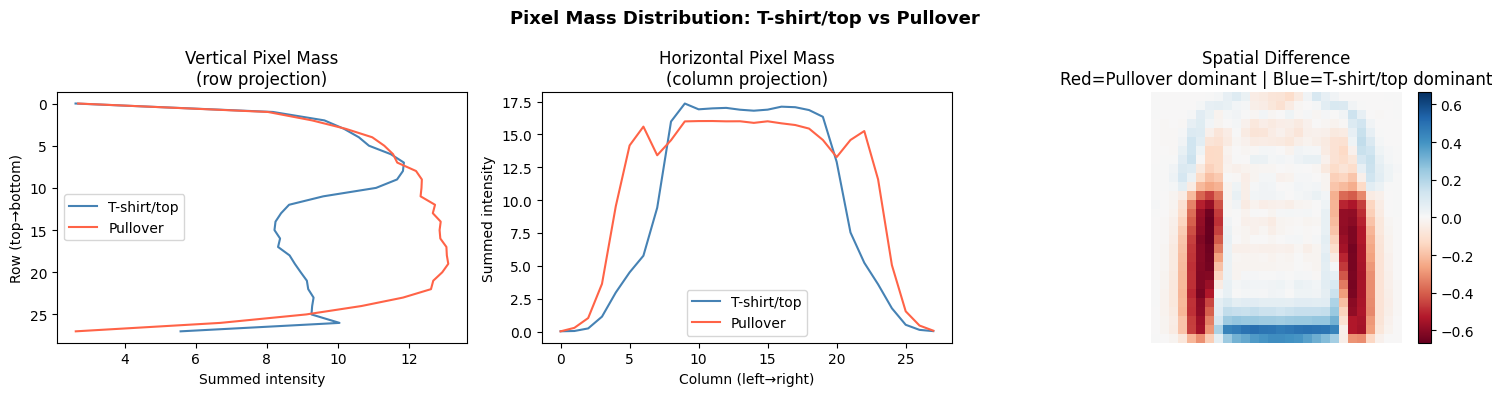

In [ ]:
plot_pixel_mass(imagesa, imagesb, class_a, class_b)

In [ ]:
#  Build Di once for D-WKM
print("Building distance matrix...")
Di = build_distance_matrix(distributions)
print(f"Done. Shape: {Di.shape}\n")

Building distance matrix...
Done. Shape: (180, 180)



In [ ]:
# ── 1. Setup — Fashion-MNIST
K = 2
R = 30  # number of random restarts
seeds = [42, 21, 7, 13, 99, 1, 55, 123, 77, 33,
         17, 82, 256, 512, 64, 101, 200, 37, 150, 29,
         88, 15, 202, 9, 50, 3, 75, 111, 222, 333]

# R = 50  # number of random restarts
# seeds = [42, 21, 7, 13, 99, 1, 55, 123, 77, 33,
#          17, 82, 256, 512, 64, 101, 200, 37, 150, 29,
#          88, 15, 202, 9, 50, 3, 75, 111, 222, 333,
#          5, 11, 23, 31, 44, 66, 100, 128, 144, 169,
#          180, 199, 240, 300, 365, 400, 500, 600, 777, 1000]

# ── 2. Multiple restarts for D-WKM (random init)
print("="*60)
print("D-WKM — RANDOM INITIALISATION")
print("="*60)
dwkm_random_results = []
for r, seed in enumerate(seeds):
    print(f"\nRestart {r+1}/{R} (seed={seed})")
    groups, obj_history = run_DWKM_with_Di(Di, K=K, max_iter=100, seed=seed, init='random')
    acc, nmi, ari = evaluate_clustering(groups, true_labels, K)
    dwkm_random_results.append({
        'seed': seed, 'groups': groups,
        'obj': obj_history[-1], 'acc': acc, 'nmi': nmi, 'ari': ari
    })
    print(f"  Accuracy={acc:.4f}, NMI={nmi:.4f}, ARI={ari:.4f}, Obj={obj_history[-1]:.4f}")

best_dwkm_random = min(dwkm_random_results, key=lambda x: x['obj'])
print(f"\nBest run (seed={best_dwkm_random['seed']}):")
print_cluster_composition(best_dwkm_random['groups'], true_labels)

# ── 3. Multiple restarts for D-WKM (K-means++ init)
print("\n" + "="*60)
print("D-WKM — K-MEANS++ INITIALISATION")
print("="*60)
dwkm_pp_results = []
for r, seed in enumerate(seeds):
    print(f"\nRestart {r+1}/{R} (seed={seed})")
    groups, obj_history = run_DWKM_with_Di(Di, K=K, max_iter=100, seed=seed, init='plus')
    acc, nmi, ari = evaluate_clustering(groups, true_labels, K)
    dwkm_pp_results.append({
        'seed': seed, 'groups': groups,
        'obj': obj_history[-1], 'acc': acc, 'nmi': nmi, 'ari': ari
    })
    print(f"  Accuracy={acc:.4f}, NMI={nmi:.4f}, ARI={ari:.4f}, Obj={obj_history[-1]:.4f}")

best_dwkm_pp = min(dwkm_pp_results, key=lambda x: x['obj'])
print(f"\nBest run (seed={best_dwkm_pp['seed']}):")
print_cluster_composition(best_dwkm_pp['groups'], true_labels)


D-WKM — RANDOM INITIALISATION

Restart 1/30 (seed=42)
Converged at iteration 6
Final: objective=1.0137, sizes=[89, 91]
  Accuracy=0.8722, NMI=0.4658, ARI=0.5517, Obj=1.0137

Restart 2/30 (seed=21)
Converged at iteration 10
Final: objective=1.0803, sizes=[139, 41]
  Accuracy=0.5611, NMI=0.0045, ARI=0.0075, Obj=1.0803

Restart 3/30 (seed=7)
Converged at iteration 6
Final: objective=1.0164, sizes=[90, 90]
  Accuracy=0.9111, NMI=0.5904, ARI=0.6743, Obj=1.0164

Restart 4/30 (seed=13)
Converged at iteration 8
Final: objective=1.0803, sizes=[41, 139]
  Accuracy=0.5611, NMI=0.0045, ARI=0.0075, Obj=1.0803

Restart 5/30 (seed=99)
Converged at iteration 2
Final: objective=1.3386, sizes=[178, 2]
  Accuracy=0.5556, NMI=0.0002, ARI=0.0003, Obj=1.3386

Restart 6/30 (seed=1)
Converged at iteration 7
Final: objective=1.0137, sizes=[89, 91]
  Accuracy=0.8722, NMI=0.4658, ARI=0.5517, Obj=1.0137

Restart 7/30 (seed=55)
Converged at iteration 5
Final: objective=1.0164, sizes=[90, 90]
  Accuracy=0.9111, NMI

In [ ]:
# ── 4. Multiple restarts for K-means
print("\n" + "="*60)
print("K-MEANS — MULTIPLE RESTARTS")
print("="*60)
kmeans_results = []
for r, seed in enumerate(seeds):
    print(f"\nRestart {r+1}/{R} (seed={seed})")
    km = KMeans(n_clusters=K, random_state=seed, n_init=1)
    km.fit(X)
    groups = labels_to_groups(km.labels_, K)
    acc, nmi, ari = evaluate_clustering(groups, true_labels, K)
    kmeans_results.append({
        'seed': seed, 'groups': groups,
        'obj': km.inertia_, 'acc': acc, 'nmi': nmi, 'ari': ari
    })
    print(f"  Accuracy={acc:.4f}, NMI={nmi:.4f}, ARI={ari:.4f}, Inertia={km.inertia_:.4f}")

best_kmeans = min(kmeans_results, key=lambda x: x['obj'])
print(f"\nBest run (seed={best_kmeans['seed']}):")
print_cluster_composition(best_kmeans['groups'], true_labels)

# ── 5. Multiple restarts for GMM
print("\n" + "="*60)
print("GMM (full) — MULTIPLE RESTARTS")
print("="*60)
gmm_results = []
for r, seed in enumerate(seeds):
    print(f"\nRestart {r+1}/{R} (seed={seed})")
    gmm = GaussianMixture(n_components=K, covariance_type='full',
                          random_state=seed, n_init=1, max_iter=200)
    gmm.fit(X)
    groups = labels_to_groups(gmm.predict(X), K)
    acc, nmi, ari = evaluate_clustering(groups, true_labels, K)
    gmm_results.append({
        'seed': seed, 'groups': groups,
        'obj': -gmm.lower_bound_, 'acc': acc, 'nmi': nmi, 'ari': ari
    })
    print(f"  Accuracy={acc:.4f}, NMI={nmi:.4f}, ARI={ari:.4f}, Lower bound={gmm.lower_bound_:.4f}")

best_gmm = min(gmm_results, key=lambda x: x['obj'])
print(f"\nBest run (seed={best_gmm['seed']}):")
print_cluster_composition(best_gmm['groups'], true_labels)


K-MEANS — MULTIPLE RESTARTS

Restart 1/30 (seed=42)
  Accuracy=0.8722, NMI=0.5100, ARI=0.5517, Inertia=7893.8735

Restart 2/30 (seed=21)
  Accuracy=0.6389, NMI=0.0605, ARI=0.0720, Inertia=7279.7283

Restart 3/30 (seed=7)
  Accuracy=0.8500, NMI=0.4481, ARI=0.4867, Inertia=7348.2711

Restart 4/30 (seed=13)
  Accuracy=0.6278, NMI=0.0501, ARI=0.0601, Inertia=7279.3899

Restart 5/30 (seed=99)
  Accuracy=0.6389, NMI=0.0605, ARI=0.0720, Inertia=7279.7283

Restart 6/30 (seed=1)
  Accuracy=0.8722, NMI=0.5100, ARI=0.5517, Inertia=7893.8735

Restart 7/30 (seed=55)
  Accuracy=0.8278, NMI=0.4030, ARI=0.4259, Inertia=7348.9334

Restart 8/30 (seed=123)
  Accuracy=0.8389, NMI=0.4252, ARI=0.4558, Inertia=7348.0840

Restart 9/30 (seed=77)
  Accuracy=0.8889, NMI=0.5656, ARI=0.6027, Inertia=7888.9152

Restart 10/30 (seed=33)
  Accuracy=0.6389, NMI=0.0605, ARI=0.0720, Inertia=7279.7283

Restart 11/30 (seed=17)
  Accuracy=0.6389, NMI=0.0580, ARI=0.0720, Inertia=7278.4467

Restart 12/30 (seed=82)
  Accuracy

In [ ]:
print("FINAL SUMMARY — FASHION-MNIST")
print("="*120)
print(f"{'Method':<30} {'Accuracy':<35} {'NMI':<40}  {'ARI':<5}")
print("-"*120)
summarise(dwkm_random_results, "D-WKM (random init)")
summarise(dwkm_pp_results,     "D-WKM (K-means++ init)")
summarise(kmeans_results,      "K-means")
summarise(gmm_results,         "GMM (full)")

FINAL SUMMARY — FASHION-MNIST
Method                         Accuracy                            NMI                                       ARI  
------------------------------------------------------------------------------------------------------------------------
D-WKM (random init)            acc: 0.7213 +/- 0.1617 (best=0.9111)  nmi: 0.2573 +/- 0.2583  ari: 0.2951 +/- 0.2946
D-WKM (K-means++ init)         acc: 0.7287 +/- 0.1572 (best=0.9111)  nmi: 0.2628 +/- 0.2537  ari: 0.3026 +/- 0.2892
K-means                        acc: 0.7526 +/- 0.1072 (best=0.8889)  nmi: 0.2725 +/- 0.2021  ari: 0.2971 +/- 0.2137
GMM (full)                     acc: 0.7526 +/- 0.1072 (best=0.8889)  nmi: 0.2725 +/- 0.2021  ari: 0.2971 +/- 0.2137


## Sandal vs Sneaker (Poorly Separated Distributions)

In [ ]:
# Fashion-MNIST classes:
# 0: T-shirt/top, 1: Trouser, 2: Pullover, 3: Dress, 4: Coat
# 5: Sandal, 6: Shirt, 7: Sneaker, 8: Bag, 9: Ankle boot

# Select two classes
class_a = 5
class_b = 7

mask0 = (y_train_full == class_a)
mask5 = (y_train_full == class_b)
imagesa = x_train_full[mask0][:100]
imagesb = x_train_full[mask5][:80]
images  = np.concatenate([imagesa, imagesb], axis=0)

distributions = [image_to_distribution(images[i]) for i in range(len(images))]
true_labels   = np.array([class_a]*100 + [class_b]*80)
X = images.reshape(len(images), 784)   # for K-means and GMM

Head count check: 100 images of class 5, 80 images of class 7


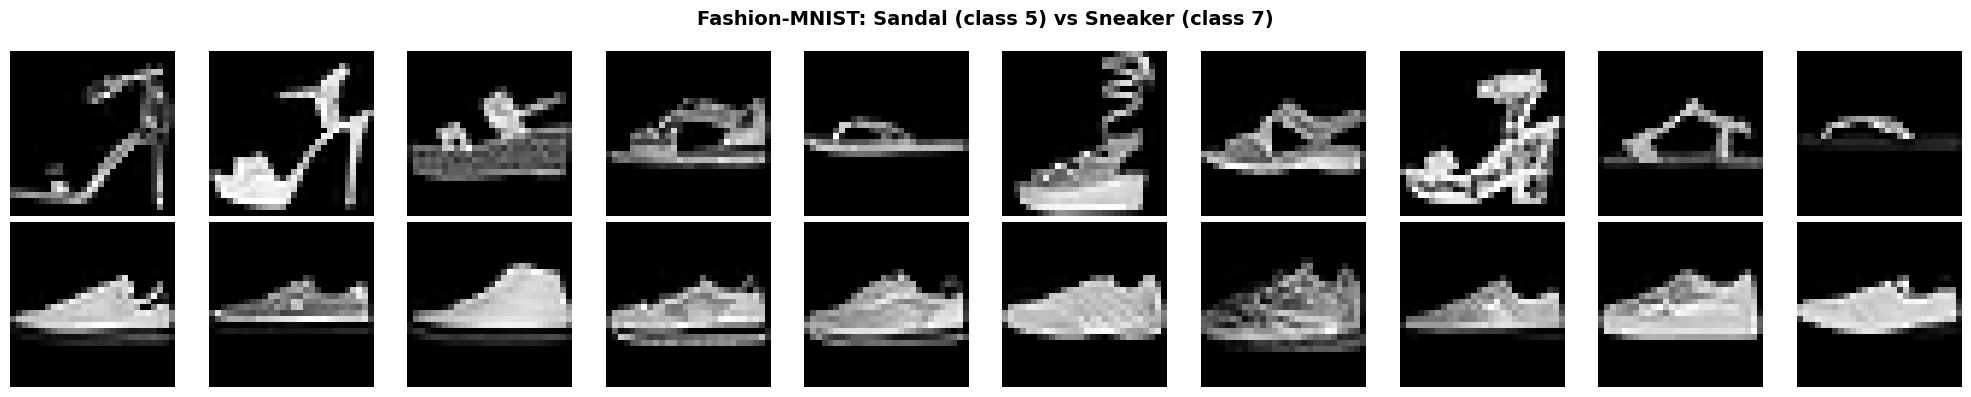

In [ ]:
print(f"Head count check: {len(imagesa)} images of class {class_a}, {len(imagesb)} images of class {class_b}")
visualize_fashion_mnist_samples(imagesa, imagesb, class_a, class_b, n_samples=10)

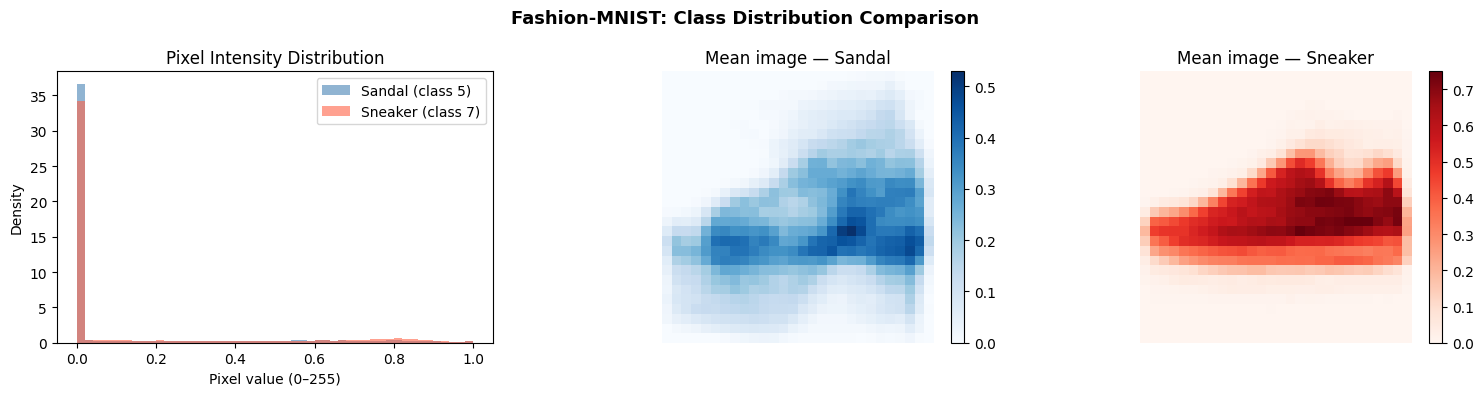

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# --- Plot 1: Overlapping histograms ---
ax = axes[0]
ax.hist(imagesa.flatten(), bins=50, alpha=0.6, color='steelblue', density=True, label='Sandal (class 5)')
ax.hist(imagesb.flatten(), bins=50, alpha=0.6, color='tomato',    density=True, label='Sneaker (class 7)')
ax.set_title('Pixel Intensity Distribution')
ax.set_xlabel('Pixel value (0–255)')
ax.set_ylabel('Density')
ax.legend()

# --- Plot 2: Mean image per class ---
for i, (imgs, label, cmap_color) in enumerate([(imagesa, 'Sandal', 'Blues'),
                                                (imagesb, 'Sneaker',      'Reds')]):
    ax = axes[i + 1]
    mean_img = imgs.mean(axis=0)
    im = ax.imshow(mean_img, cmap=cmap_color)
    ax.set_title(f'Mean image — {label}')
    ax.axis('off')
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.suptitle('Fashion-MNIST: Class Distribution Comparison', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

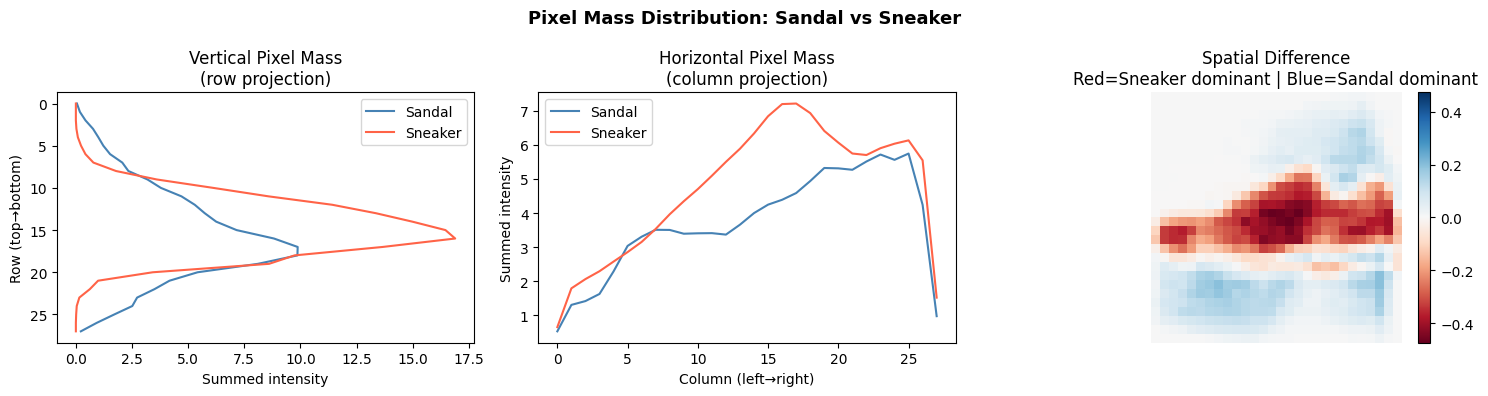

In [ ]:
plot_pixel_mass(imagesa, imagesb, class_a, class_b)

In [ ]:
# ── . Build Di once for D-WKM
print("Building distance matrix...")
Di = build_distance_matrix(distributions)
print(f"Done. Shape: {Di.shape}\n")

Building distance matrix...
Done. Shape: (180, 180)



In [ ]:
# ── 1. Setup — Fashion-MNIST
K = 2
R = 30  # number of random restarts
seeds = [42, 21, 7, 13, 99, 1, 55, 123, 77, 33,
         17, 82, 256, 512, 64, 101, 200, 37, 150, 29,
         88, 15, 202, 9, 50, 3, 75, 111, 222, 333]

# ── 2. Multiple restarts for D-WKM (random init)
print("="*60)
print("D-WKM — RANDOM INITIALISATION")
print("="*60)
dwkm_random_results = []
for r, seed in enumerate(seeds):
    print(f"\nRestart {r+1}/{R} (seed={seed})")
    groups, obj_history = run_DWKM_with_Di(Di, K=K, max_iter=100, seed=seed, init='random')
    acc, nmi, ari = evaluate_clustering(groups, true_labels, K)
    dwkm_random_results.append({
        'seed': seed, 'groups': groups,
        'obj': obj_history[-1], 'acc': acc, 'nmi': nmi, 'ari': ari
    })
    print(f"  Accuracy={acc:.4f}, NMI={nmi:.4f}, ARI={ari:.4f}, Obj={obj_history[-1]:.4f}")

best_dwkm_random = min(dwkm_random_results, key=lambda x: x['obj'])
print(f"\nBest run (seed={best_dwkm_random['seed']}):")
print_cluster_composition(best_dwkm_random['groups'], true_labels)

# ── 3. Multiple restarts for D-WKM (K-means++ init)
print("\n" + "="*60)
print("D-WKM — K-MEANS++ INITIALISATION")
print("="*60)
dwkm_pp_results = []
for r, seed in enumerate(seeds):
    print(f"\nRestart {r+1}/{R} (seed={seed})")
    groups, obj_history = run_DWKM_with_Di(Di, K=K, max_iter=100, seed=seed, init='plus')
    acc, nmi, ari = evaluate_clustering(groups, true_labels, K)
    dwkm_pp_results.append({
        'seed': seed, 'groups': groups,
        'obj': obj_history[-1], 'acc': acc, 'nmi': nmi, 'ari': ari
    })
    print(f"  Accuracy={acc:.4f}, NMI={nmi:.4f}, ARI={ari:.4f}, Obj={obj_history[-1]:.4f}")

best_dwkm_pp = min(dwkm_pp_results, key=lambda x: x['obj'])
print(f"\nBest run (seed={best_dwkm_pp['seed']}):")
print_cluster_composition(best_dwkm_pp['groups'], true_labels)


D-WKM — RANDOM INITIALISATION

Restart 1/30 (seed=42)
Converged at iteration 5
Final: objective=2.0787, sizes=[151, 29]
  Accuracy=0.5833, NMI=0.1161, ARI=0.0193, Obj=2.0787

Restart 2/30 (seed=21)
Converged at iteration 4
Final: objective=2.0787, sizes=[151, 29]
  Accuracy=0.5833, NMI=0.1161, ARI=0.0193, Obj=2.0787

Restart 3/30 (seed=7)
Converged at iteration 5
Final: objective=2.0879, sizes=[152, 28]
  Accuracy=0.5778, NMI=0.1106, ARI=0.0156, Obj=2.0879

Restart 4/30 (seed=13)
Converged at iteration 7
Final: objective=2.0787, sizes=[29, 151]
  Accuracy=0.5833, NMI=0.1161, ARI=0.0193, Obj=2.0787

Restart 5/30 (seed=99)
Converged at iteration 5
Final: objective=2.0879, sizes=[152, 28]
  Accuracy=0.5778, NMI=0.1106, ARI=0.0156, Obj=2.0879

Restart 6/30 (seed=1)
Converged at iteration 5
Final: objective=2.0879, sizes=[28, 152]
  Accuracy=0.5778, NMI=0.1106, ARI=0.0156, Obj=2.0879

Restart 7/30 (seed=55)
Converged at iteration 6
Final: objective=2.0879, sizes=[28, 152]
  Accuracy=0.5778,

In [ ]:
# ── 4. Multiple restarts for K-means
print("\n" + "="*60)
print("K-MEANS — MULTIPLE RESTARTS")
print("="*60)
kmeans_results = []
for r, seed in enumerate(seeds):
    print(f"\nRestart {r+1}/{R} (seed={seed})")
    km = KMeans(n_clusters=K, random_state=seed, n_init=1)
    km.fit(X)
    groups = labels_to_groups(km.labels_, K)
    acc, nmi, ari = evaluate_clustering(groups, true_labels, K)
    kmeans_results.append({
        'seed': seed, 'groups': groups,
        'obj': km.inertia_, 'acc': acc, 'nmi': nmi, 'ari': ari
    })
    print(f"  Accuracy={acc:.4f}, NMI={nmi:.4f}, ARI={ari:.4f}, Inertia={km.inertia_:.4f}")

best_kmeans = min(kmeans_results, key=lambda x: x['obj'])
print(f"\nBest run (seed={best_kmeans['seed']}):")
print_cluster_composition(best_kmeans['groups'], true_labels)

# ── 5. Multiple restarts for GMM
print("\n" + "="*60)
print("GMM (full) — MULTIPLE RESTARTS")
print("="*60)
gmm_results = []
for r, seed in enumerate(seeds):
    print(f"\nRestart {r+1}/{R} (seed={seed})")
    gmm = GaussianMixture(n_components=K, covariance_type='full',
                          random_state=seed, n_init=1, max_iter=200)
    gmm.fit(X)
    groups = labels_to_groups(gmm.predict(X), K)
    acc, nmi, ari = evaluate_clustering(groups, true_labels, K)
    gmm_results.append({
        'seed': seed, 'groups': groups,
        'obj': -gmm.lower_bound_, 'acc': acc, 'nmi': nmi, 'ari': ari
    })
    print(f"  Accuracy={acc:.4f}, NMI={nmi:.4f}, ARI={ari:.4f}, Lower bound={gmm.lower_bound_:.4f}")

best_gmm = min(gmm_results, key=lambda x: x['obj'])
print(f"\nBest run (seed={best_gmm['seed']}):")
print_cluster_composition(best_gmm['groups'], true_labels)


K-MEANS — MULTIPLE RESTARTS

Restart 1/30 (seed=42)
  Accuracy=0.6944, NMI=0.2055, ARI=0.1455, Inertia=5478.1682

Restart 2/30 (seed=21)
  Accuracy=0.8667, NMI=0.4333, ARI=0.5352, Inertia=5468.7996

Restart 3/30 (seed=7)
  Accuracy=0.8611, NMI=0.4154, ARI=0.5189, Inertia=5470.0487

Restart 4/30 (seed=13)
  Accuracy=0.7611, NMI=0.2679, ARI=0.2684, Inertia=5467.4727

Restart 5/30 (seed=99)
  Accuracy=0.8667, NMI=0.4333, ARI=0.5352, Inertia=5468.7996

Restart 6/30 (seed=1)
  Accuracy=0.8667, NMI=0.4333, ARI=0.5352, Inertia=5468.7996

Restart 7/30 (seed=55)
  Accuracy=0.6944, NMI=0.2188, ARI=0.1454, Inertia=5477.3955

Restart 8/30 (seed=123)
  Accuracy=0.6944, NMI=0.2188, ARI=0.1454, Inertia=5477.3955

Restart 9/30 (seed=77)
  Accuracy=0.7611, NMI=0.2781, ARI=0.2684, Inertia=5467.4091

Restart 10/30 (seed=33)
  Accuracy=0.6944, NMI=0.2188, ARI=0.1454, Inertia=5477.3955

Restart 11/30 (seed=17)
  Accuracy=0.7333, NMI=0.2411, ARI=0.2129, Inertia=5472.2609

Restart 12/30 (seed=82)
  Accuracy

In [ ]:
print("FINAL SUMMARY — FASHION-MNIST")
print("="*120)
print(f"{'Method':<30} {'Accuracy':<35} {'NMI':<40}  {'ARI':<5}")
print("-"*120)
summarise(dwkm_random_results, "D-WKM (random init)")
summarise(dwkm_pp_results,     "D-WKM (K-means++ init)")
summarise(kmeans_results,      "K-means")
summarise(gmm_results,         "GMM (full)")

FINAL SUMMARY — FASHION-MNIST
Method                         Accuracy                            NMI                                       ARI  
------------------------------------------------------------------------------------------------------------------------
D-WKM (random init)            acc: 0.5804 +/- 0.0053 (best=0.5833)  nmi: 0.1102 +/- 0.0206  ari: 0.0173 +/- 0.0037
D-WKM (K-means++ init)         acc: 0.5809 +/- 0.0028 (best=0.5833)  nmi: 0.1137 +/- 0.0027  ari: 0.0177 +/- 0.0018
K-means                        acc: 0.7769 +/- 0.0751 (best=0.8667)  nmi: 0.3143 +/- 0.0957  ari: 0.3249 +/- 0.1708
GMM (full)                     acc: 0.7769 +/- 0.0751 (best=0.8667)  nmi: 0.3143 +/- 0.0957  ari: 0.3249 +/- 0.1708


We further visualize in details about the cluster samples in this worst case example performance of D-BWKM.

In [ ]:
def visualize_cluster_prototypes(final_groups, images, K, title="Cluster Prototypes"):
    """
    Display the average image (prototype) for each cluster. Note that this image is artificial as it is the average of the images in the cluster, not an actual image
    """
    fig, axes = plt.subplots(1, K, figsize=(3*K, 4))
    if K == 1:
        axes = [axes]

    for k in range(K):
        cluster_indices = final_groups[k]
        cluster_images = images[cluster_indices]

        prototype = cluster_images.mean(axis=0)

        axes[k].imshow(prototype, cmap='gray')
        axes[k].set_title(f"Cluster {k}\n(size={len(cluster_indices)})")
        axes[k].axis('off')

    plt.suptitle(title, fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

In [ ]:
def visualize_cluster_samples(final_groups, images, true_labels, K, n_samples=10, title=""):
    """Helper function to show sample images from each cluster."""
    class_names = {
        0: 'T-shirt', 1: 'Trouser', 2: 'Pullover', 3: 'Dress', 4: 'Coat',
        5: 'Sandal', 6: 'Shirt', 7: 'Sneaker', 8: 'Bag', 9: 'Ankle boot'
    }

    fig, axes = plt.subplots(K, n_samples, figsize=(2*n_samples, 2*K))
    if K == 1:
        axes = [axes]

    for k in range(K):
        cluster_indices = final_groups[k]
        sample_idx = np.random.choice(cluster_indices,
                                      size=min(n_samples, len(cluster_indices)),
                                      replace=False)

        for i, idx in enumerate(sample_idx):
            axes[k, i].imshow(images[idx], cmap='gray')
            true_class = true_labels[idx]
            axes[k, i].set_title(f"{class_names.get(true_class, true_class)}", fontsize=8)
            axes[k, i].axis('off')

        axes[k, 0].set_ylabel(f"Cluster {k}\n(size={len(cluster_indices)})",
                             fontsize=9, fontweight='bold')

    plt.suptitle(title if title else "Sample Images from Each Cluster",
                 fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

In [ ]:
results_dict = {
    'D-WKM (random)': best_dwkm_random['groups'],
    'D-WKM (K-means++)': best_dwkm_pp['groups'],
    'K-means': best_kmeans['groups'],
    'GMM': best_gmm['groups']
}



D-WKM (RANDOM INIT) — DETAILED VISUALIZATION


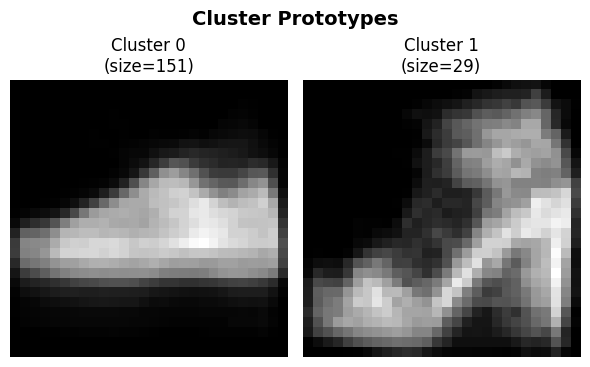

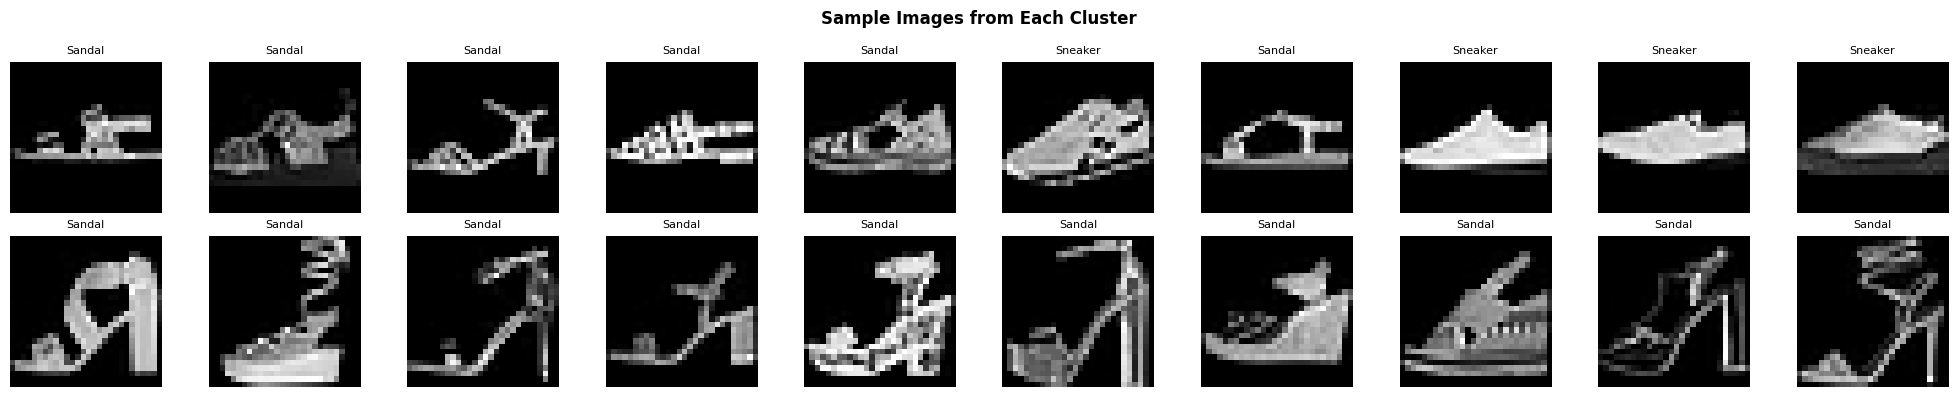

In [ ]:
# ── D-WKM (random)
print("\n" + "="*80)
print("D-WKM (RANDOM INIT) — DETAILED VISUALIZATION")
print("="*80)D-WKM (random init)            acc: 0.5804 +/- 0.0053 (best=0.5833)  nmi: 0.1102 +/- 0.0206  ari: 0.0173 +/- 0.0037
D-WKM (K-means++ init)         acc: 0.5809 +/- 0.0028 (best=0.5833)  nmi: 0.1137 +/- 0.0027  ari: 0.0177 +/- 0.0018
K-means                        acc: 0.7769 +/- 0.0751 (best=0.8667)  nmi: 0.3143 +/- 0.0957  ari: 0.3249 +/- 0.1708
GMM (full)                     acc: 0.7769 +/- 0.0751 (best=0.8667)  nmi: 0.3143 +/- 0.0957  ari: 0.3249 +/- 0.1708
visualize_cluster_prototypes(best_dwkm_random['groups'], images, K=2)
visualize_cluster_samples(best_dwkm_random['groups'], images, true_labels, K=2, n_samples=10)



D-WKM (K-MEANS++ INIT) — DETAILED VISUALIZATION


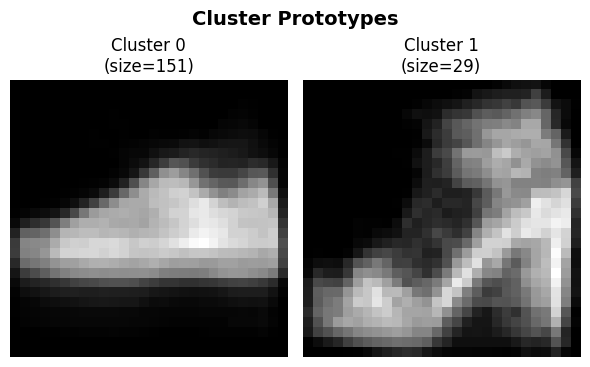

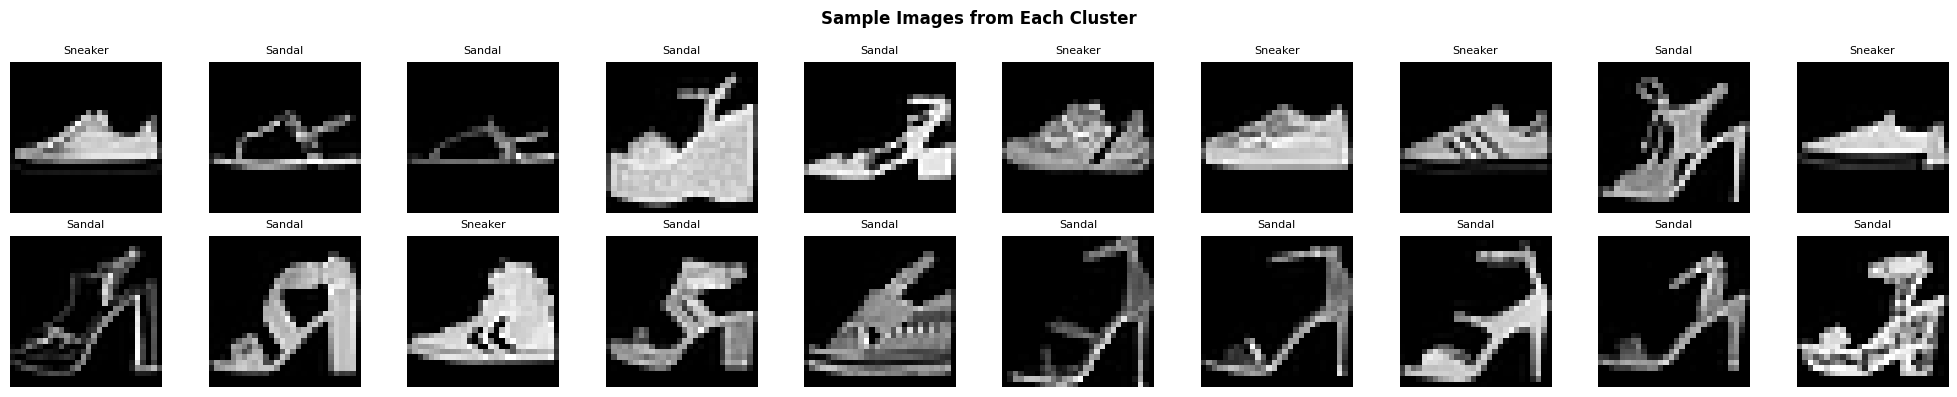

In [ ]:
# ── D-WKM (K-means++)
print("\n" + "="*80)
print("D-WKM (K-MEANS++ INIT) — DETAILED VISUALIZATION")
print("="*80)
visualize_cluster_prototypes(best_dwkm_pp['groups'], images, K=2)
visualize_cluster_samples(best_dwkm_pp['groups'], images, true_labels, K=2, n_samples=10)



K-MEANS — DETAILED VISUALIZATION


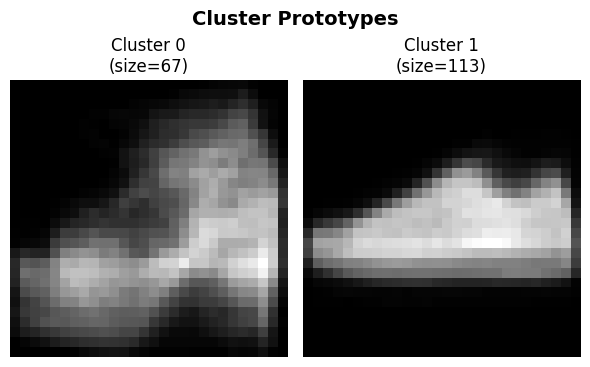

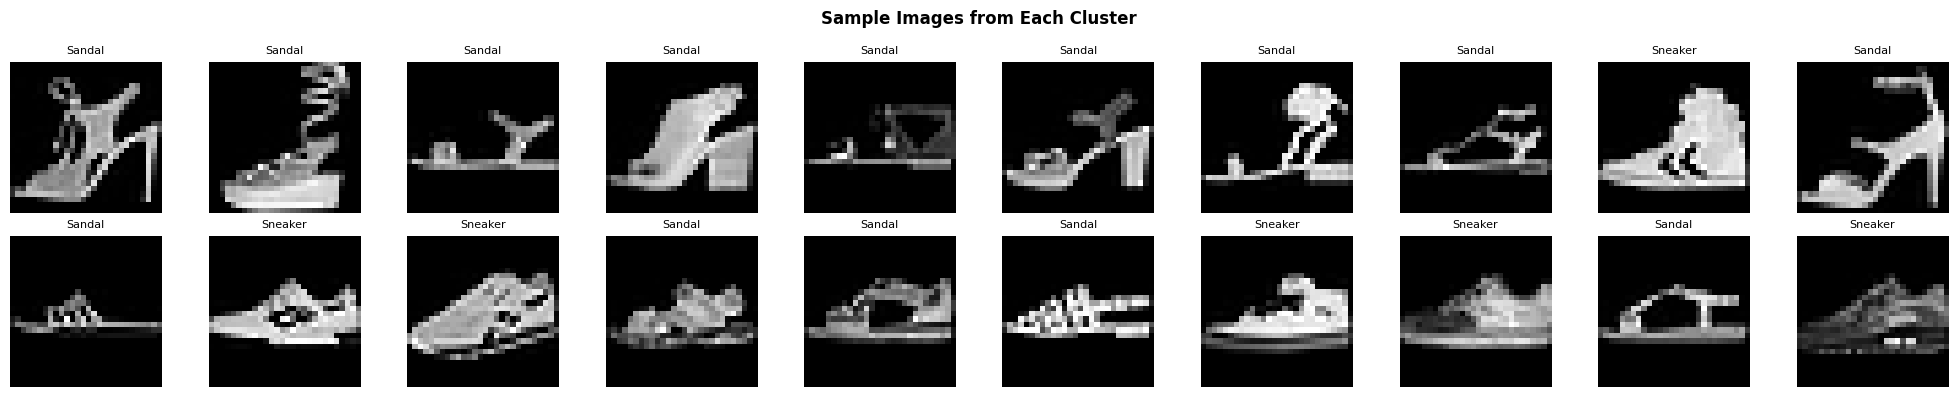

In [ ]:
# ── K-means
print("\n" + "="*80)
print("K-MEANS — DETAILED VISUALIZATION")
print("="*80)
visualize_cluster_prototypes(best_kmeans['groups'], images, K=2)
visualize_cluster_samples(best_kmeans['groups'], images, true_labels, K=2, n_samples=10)



GMM — DETAILED VISUALIZATION


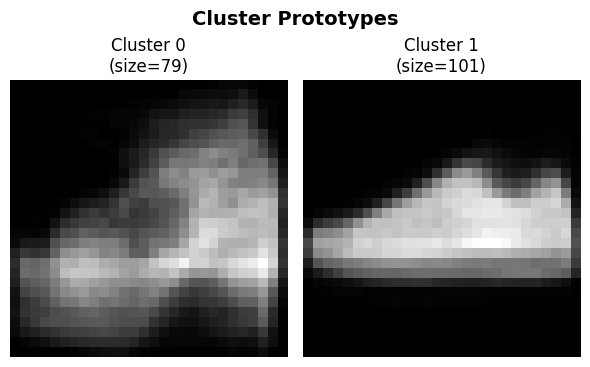

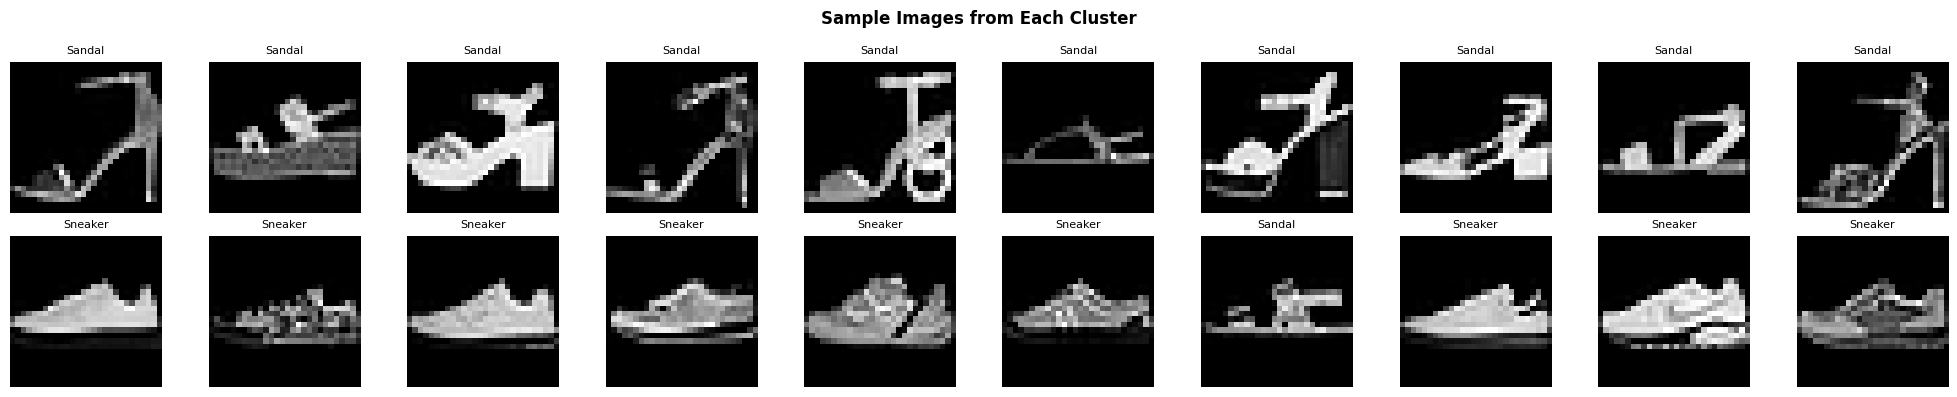

In [ ]:
# ── GMM
print("\n" + "="*80)
print("GMM — DETAILED VISUALIZATION")
print("="*80)
visualize_cluster_prototypes(best_gmm['groups'], images, K=2)
visualize_cluster_samples(best_gmm['groups'], images, true_labels, K=2, n_samples=10)

All four methods recover visually identical cluster mean prototypes.

 Despite this, D-WKM achieves near-random assignment (ACC=0.58, ARI=0.017), collapsing 151 of 180 samples into a single cluster. This failure stems directly from the W2 distance metric on raw pixel images: Wasserstein distance measures the cost of transporting pixel intensity mass between images, making it sensitive to global pixel layout rather than local semantic structure. Flat sandals and sneakers share similar pixel mass distributions despite belonging to different categories, causing W2 to assign them near-equal distances to both cluster centers, producing arbitrary and unstable assignments.

In contrast, Euclidean distance compares images pixel-by-pixel at fixed spatial positions, accidentally capturing the local structural differences — sole thickness, strap sparsity, heel concentration — that distinguish the two classes.

# Summary

**Clustering Performance Across Fashion-MNIST Class Pairs**

- **Well-Separated Distributions.** D-WKM achieves optimal clustering performance when class distributions are well-separated in Wasserstein space. For visually distinct pairs such as *T-shirt vs. Sandal* and *Trouser vs. Sneaker*, D-WKM with K-means++ initialization attains perfect or near-perfect clustering scores (Accuracy ≈ 1.0, NMI ≈ 1.0, ARI ≈ 1.0). In these cases, K-means++ initialization consistently outperforms random initialization.


- **Moderately Separated Distributions.** When class distributions have greater visual similarity, D-WKM performance degrades. For *Shirt vs. Dress*, D-WKM maintains superior clustering quality compared to baseline methods, though performance gaps narrow. However, this is the only case where K-means++ initialization underperforms relative to random initialization. For *T-shirt vs. Pullover*, D-WKM yields comparable results to standard K-means and GMM.

- **Poorly Separated Distributions**. The most challenging scenario *Sandal vs. Sneaker*. In this case, D-WKM performs significantly worse than both K-means and GMM.




**Hypothesis Conclusion:** D-WKM excels when classes have distinctly different geometric structures (different object categories), but struggles when classes share similar base geometry despite having different labels (same object category).

**D-WKM Excels When:**

- Different object categories (e.g., clothing vs. footwear)
- Mass in different regions (e.g., upper vs. lower body)
- Fundamentally different shapes (e.g., rectangle vs. foot)
- Large Wasserstein distance → Easy to separate

Example: T-shirt vs. Sandal → Perfect clustering

**D-WKM Struggles When:**

- Mass in overlapping regions (e.g., both in lower half)
- Similar base shapes (e.g., both foot-shaped)
- Small Wasserstein distance → Hard to separate


Example: Sandal vs. Sneaker → Poor clustering